# Интерпретация

In [17]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


In [2]:
pip install lime

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 58.1 MB/s  0:00:00a 0:00:01
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=20db17e34a216741e984e44a96bdb192c7d632263c9494d7856f611877bd45e3
  Stored in directory: /Users/ignatio27/Library/Caches/pip/wheels/eb/51/d9/c707b8fa7dee923cf3cb03edaf5c7f2bfeed5b91f5ca72f468
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [lime]━━━━━━ 3/5 [scikit-image]
Note: you may need to restart the kernel to use updated packages.


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [18]:
data_path = 'data/hw1_interpretation/data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [19]:
from sklearn.metrics import mean_absolute_percentage_error

RANDOM_STATE = 42

rooms_map = {'студия': 0, '1': 1, '2': 2, '3': 3, '>=4': 4}

X = data.drop(columns=['price_target']).copy()
y = data['price_target'].copy()

X['agreement_date'] = pd.to_datetime(X['agreement_date'])
X['agreement_year'] = X['agreement_date'].dt.year
X['agreement_month'] = X['agreement_date'].dt.month
X['agreement_day'] = X['agreement_date'].dt.day
X['agreement_dayofweek'] = X['agreement_date'].dt.dayofweek
X = X.drop(columns=['agreement_date'])

X['rooms_4'] = X['rooms_4'].map(rooms_map)
X['region_name_cat'] = X['region_name_cat'].astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

experiments = {
    'LinearRegression | raw': (LinearRegression(), X_train, X_test),
    'LinearRegression | scaled': (LinearRegression(), X_train_scaled, X_test_scaled),
    'Lasso | raw': (Lasso(alpha=0.1, max_iter=20000), X_train, X_test),
    'Lasso | scaled': (Lasso(alpha=0.1, max_iter=20000), X_train_scaled, X_test_scaled),
    'GradientBoostingRegressor | raw': (
        GradientBoostingRegressor(max_depth=5, random_state=RANDOM_STATE),
        X_train,
        X_test,
    ),
    'GradientBoostingRegressor | scaled': (
        GradientBoostingRegressor(max_depth=5, random_state=RANDOM_STATE),
        X_train_scaled,
        X_test_scaled,
    ),
}

rows = []
for model_name, (model, X_tr, X_te) in experiments.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    mse = mean_squared_error(y_test, y_pred)
    rows.append(
        {
            'model': model_name,
            'MSE': mse,
            'RMSE': np.sqrt(mse),
            'MAPE': mean_absolute_percentage_error(y_test, y_pred),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values('MAPE').reset_index(drop=True)
display(metrics_df.style.format({'MSE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}'}))

best_model = metrics_df.loc[0, 'model']
print(f'Лучшая модель по MAPE: {best_model}')



,model,MSE,RMSE,MAPE
0,GradientBoostingRegressor | raw,"3,603,689.35","1,898.34",0.0397
1,GradientBoostingRegressor | scaled,"3,633,079.70","1,906.06",0.0402
2,LinearRegression | scaled,"19,350,854.95","4,398.96",0.0982
3,LinearRegression | raw,"19,350,854.95","4,398.96",0.0982
4,Lasso | scaled,"20,077,970.68","4,480.84",0.1004
5,Lasso | raw,"20,326,980.20","4,508.55",0.1015


Лучшая модель по MAPE: GradientBoostingRegressor | raw


In [20]:
print('\nВыводы:')
print('- Для задачи прогнозирования цены удобнее всего смотреть на MAPE: это относительная ошибка, и её проще интерпретировать в процентах.')
print('- GradientBoostingRegressor оказался заметно сильнее линейных моделей по всем метрикам.')
print('- LinearRegression почти не меняется после масштабирования: обычный МНК почти инвариантен к линейному масштабированию признаков.')
print('- Lasso чувствителен к масштабу, потому что L1-регуляризация штрафует коэффициенты напрямую: без нормализации признаки с разным масштабом штрафуются неравномерно.')
print('- Бустинг на деревьях почти инвариантен к масштабированию, потому что деревья делают разбиения по порядку значений, а не по их абсолютному масштабу.')
print('- Это важно для анализа признаков: если модель чувствительна к масштабу, то коэффициенты и важности без нормализации можно интерпретировать неверно.')


Выводы:
- Для задачи прогнозирования цены удобнее всего смотреть на MAPE: это относительная ошибка, и её проще интерпретировать в процентах.
- GradientBoostingRegressor оказался заметно сильнее линейных моделей по всем метрикам.
- LinearRegression почти не меняется после масштабирования: обычный МНК почти инвариантен к линейному масштабированию признаков.
- Lasso чувствителен к масштабу, потому что L1-регуляризация штрафует коэффициенты напрямую: без нормализации признаки с разным масштабом штрафуются неравномерно.
- Бустинг на деревьях почти инвариантен к масштабированию, потому что деревья делают разбиения по порядку значений, а не по их абсолютному масштабу.
- Это важно для анализа признаков: если модель чувствительна к масштабу, то коэффициенты и важности без нормализации можно интерпретировать неверно.


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

,model,MSE,RMSE,MAPE
5,GradientBoostingRegressor | MinMaxScaler,"3,644,993.76","1,909.19",0.0399
4,GradientBoostingRegressor | StandardScaler,"3,633,079.70","1,906.06",0.0402
0,LinearRegression | StandardScaler,"19,350,854.95","4,398.96",0.0982
1,LinearRegression | MinMaxScaler,"19,350,854.95","4,398.96",0.0982
2,Lasso | StandardScaler,"20,077,970.68","4,480.84",0.1004
3,Lasso | MinMaxScaler,"20,204,258.95","4,494.91",0.1016


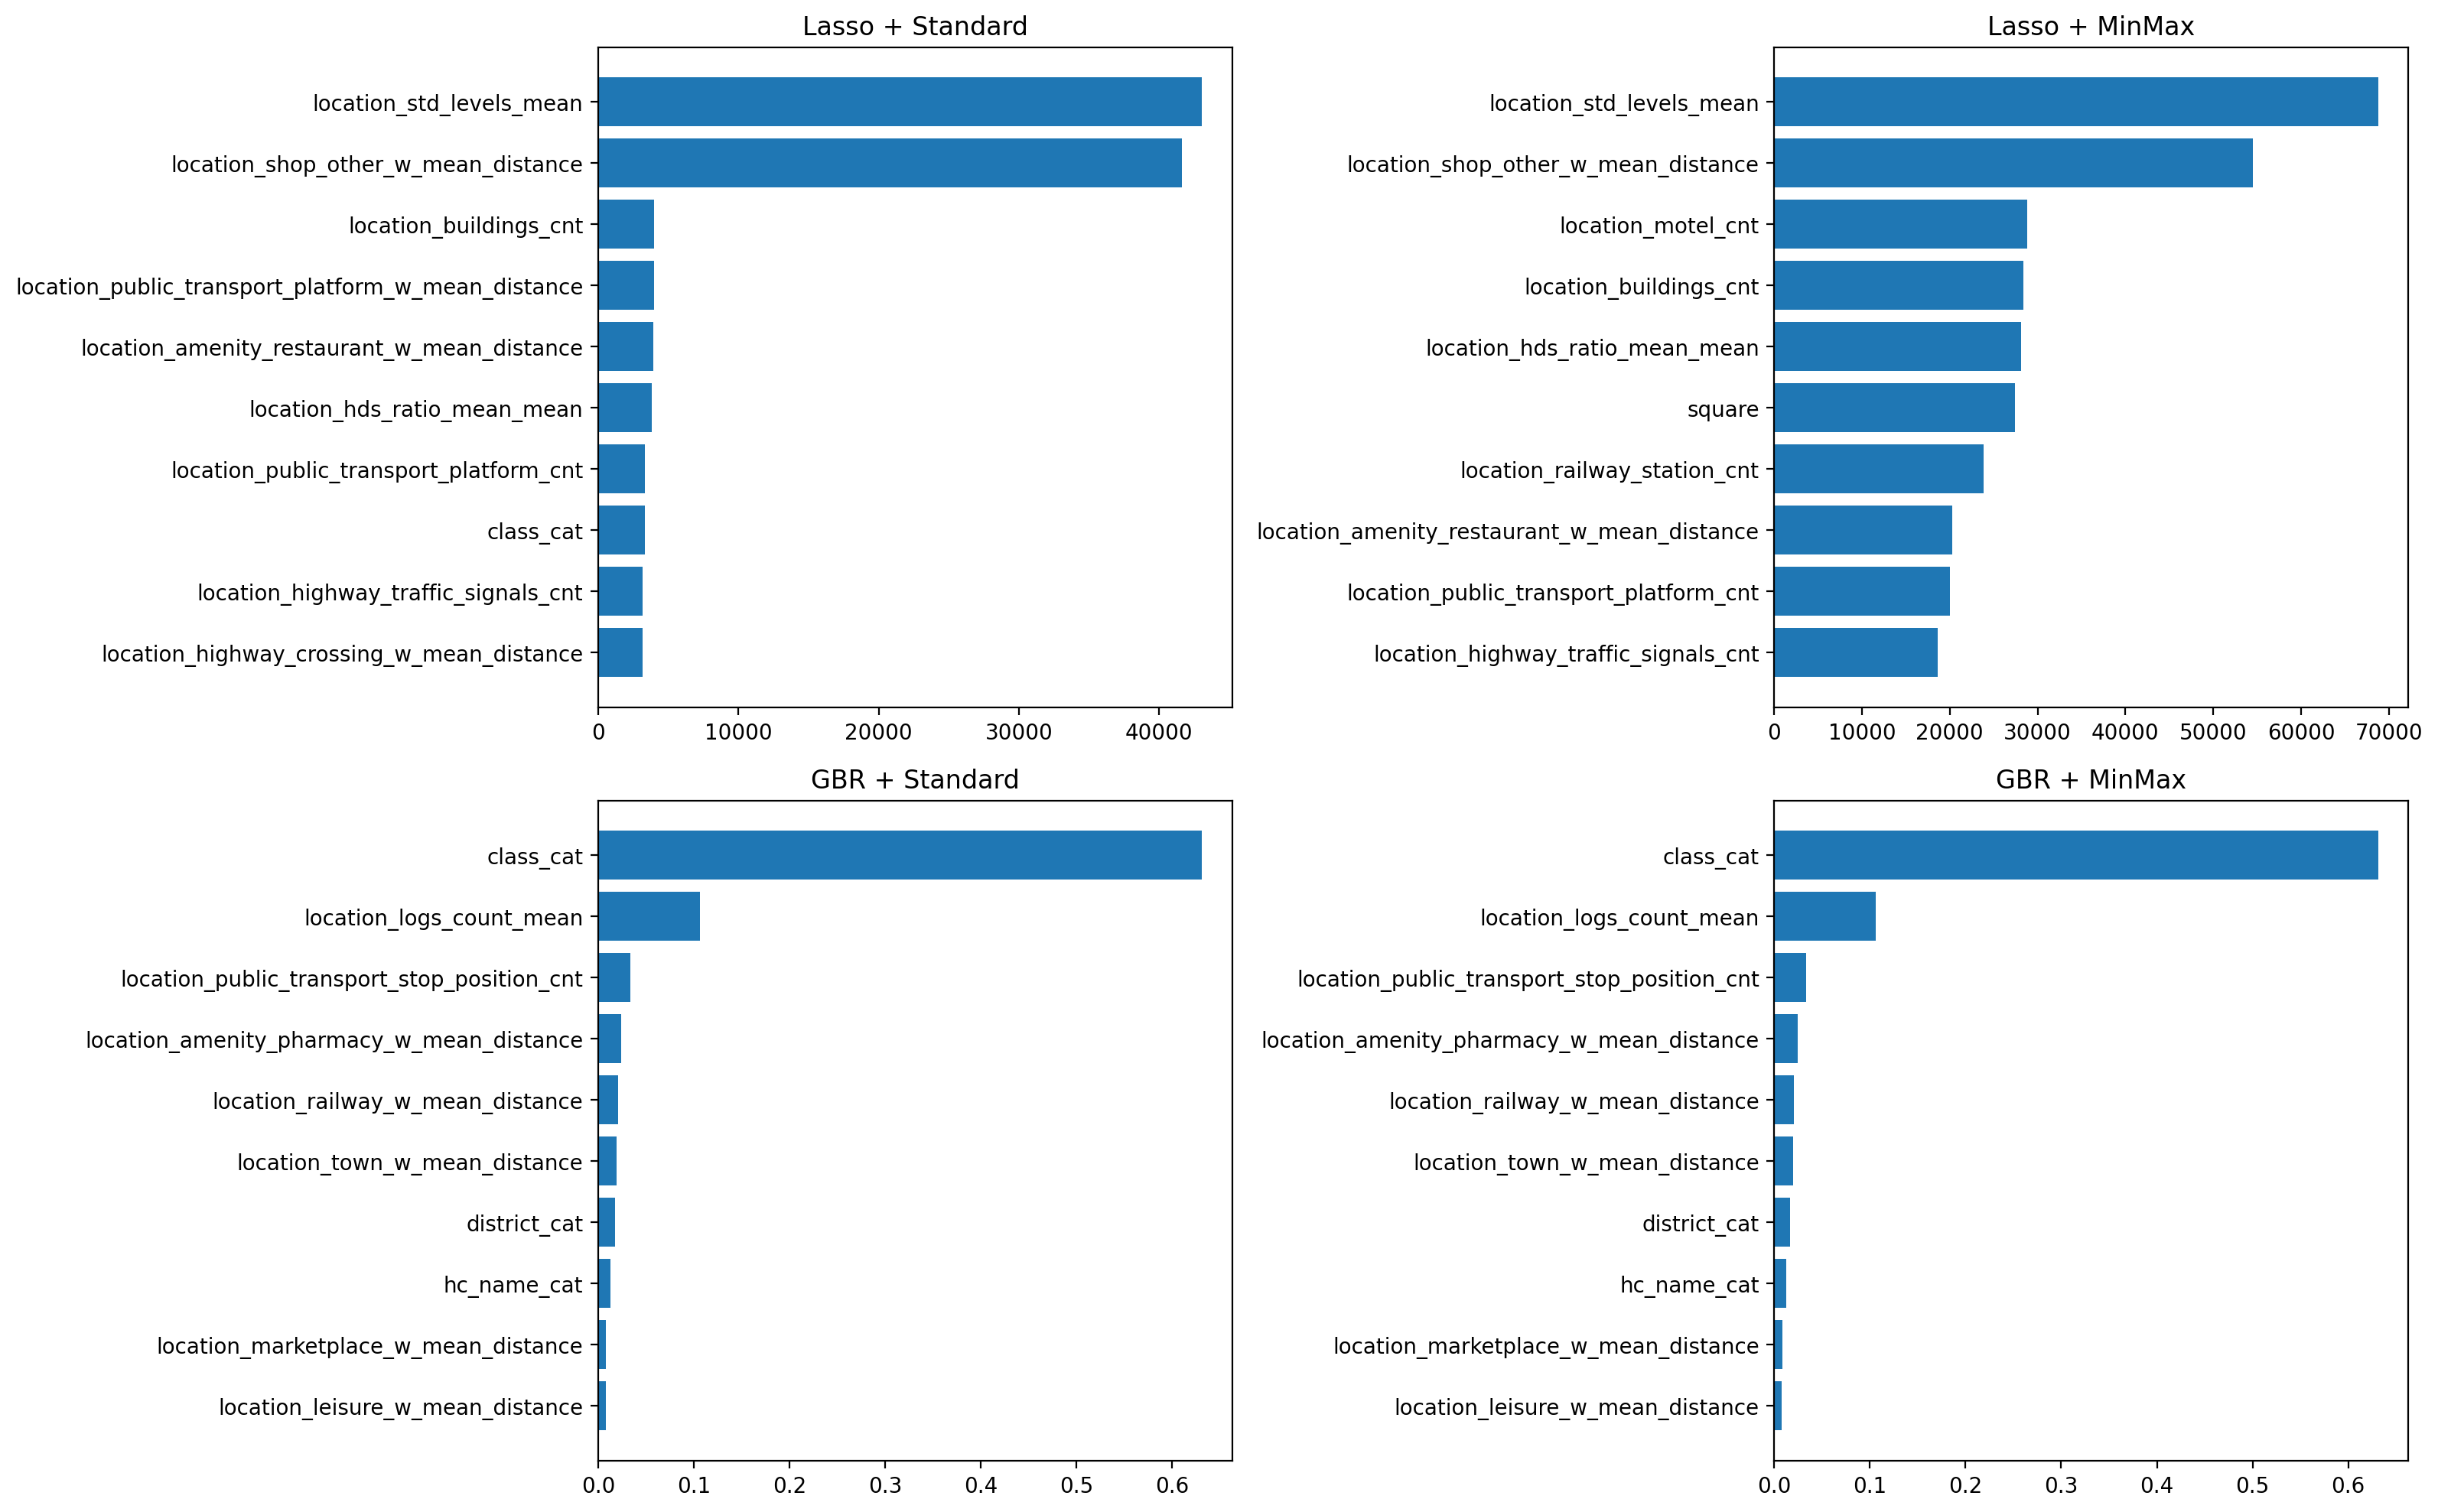

In [21]:
from sklearn.preprocessing import MinMaxScaler

feature_names = X_train.columns.tolist()
analysis_features = ['square', 'location_logs_count_mean']
numeric_features = feature_names.copy()
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_train_standard = pd.DataFrame(standard_scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_standard = pd.DataFrame(standard_scaler.transform(X_test), columns=feature_names, index=X_test.index)
X_train_minmax = pd.DataFrame(minmax_scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_minmax = pd.DataFrame(minmax_scaler.transform(X_test), columns=feature_names, index=X_test.index)

lin_standard = LinearRegression().fit(X_train_standard, y_train)
lin_minmax = LinearRegression().fit(X_train_minmax, y_train)
lasso_standard = Lasso(alpha=0.1, max_iter=20000).fit(X_train_standard, y_train)
lasso_minmax = Lasso(alpha=0.1, max_iter=20000).fit(X_train_minmax, y_train)
gbr_standard = GradientBoostingRegressor(max_depth=5, random_state=RANDOM_STATE).fit(X_train_standard, y_train)
gbr_minmax = GradientBoostingRegressor(max_depth=5, random_state=RANDOM_STATE).fit(X_train_minmax, y_train)

rows = []
for name, model, X_te in [('LinearRegression | StandardScaler', lin_standard, X_test_standard), ('LinearRegression | MinMaxScaler', lin_minmax, X_test_minmax), ('Lasso | StandardScaler', lasso_standard, X_test_standard), ('Lasso | MinMaxScaler', lasso_minmax, X_test_minmax), ('GradientBoostingRegressor | StandardScaler', gbr_standard, X_test_standard), ('GradientBoostingRegressor | MinMaxScaler', gbr_minmax, X_test_minmax)]:
    pred = model.predict(X_te)
    mse = mean_squared_error(y_test, pred)
    rows.append({'model': name, 'MSE': mse, 'RMSE': np.sqrt(mse), 'MAPE': mean_absolute_percentage_error(y_test, pred)})
display(pd.DataFrame(rows).sort_values('MAPE').style.format({'MSE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.4f}'}))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, title, s in [
    (axes[0, 0], 'Lasso + Standard', pd.Series(np.abs(lasso_standard.coef_), index=feature_names).sort_values(ascending=False).head(10).sort_values()),
    (axes[0, 1], 'Lasso + MinMax', pd.Series(np.abs(lasso_minmax.coef_), index=feature_names).sort_values(ascending=False).head(10).sort_values()),
    (axes[1, 0], 'GBR + Standard', pd.Series(gbr_standard.feature_importances_, index=feature_names).sort_values(ascending=False).head(10).sort_values()),
    (axes[1, 1], 'GBR + MinMax', pd.Series(gbr_minmax.feature_importances_, index=feature_names).sort_values(ascending=False).head(10).sort_values()),
]:
    ax.barh(s.index, s.values)
    ax.set_title(title)
plt.tight_layout()

In [22]:
print('Вывод: у Lasso важности сильнее зависят от типа нормализации, а у бустинга почти не меняются.')


Вывод: у Lasso важности сильнее зависят от типа нормализации, а у бустинга почти не меняются.


## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

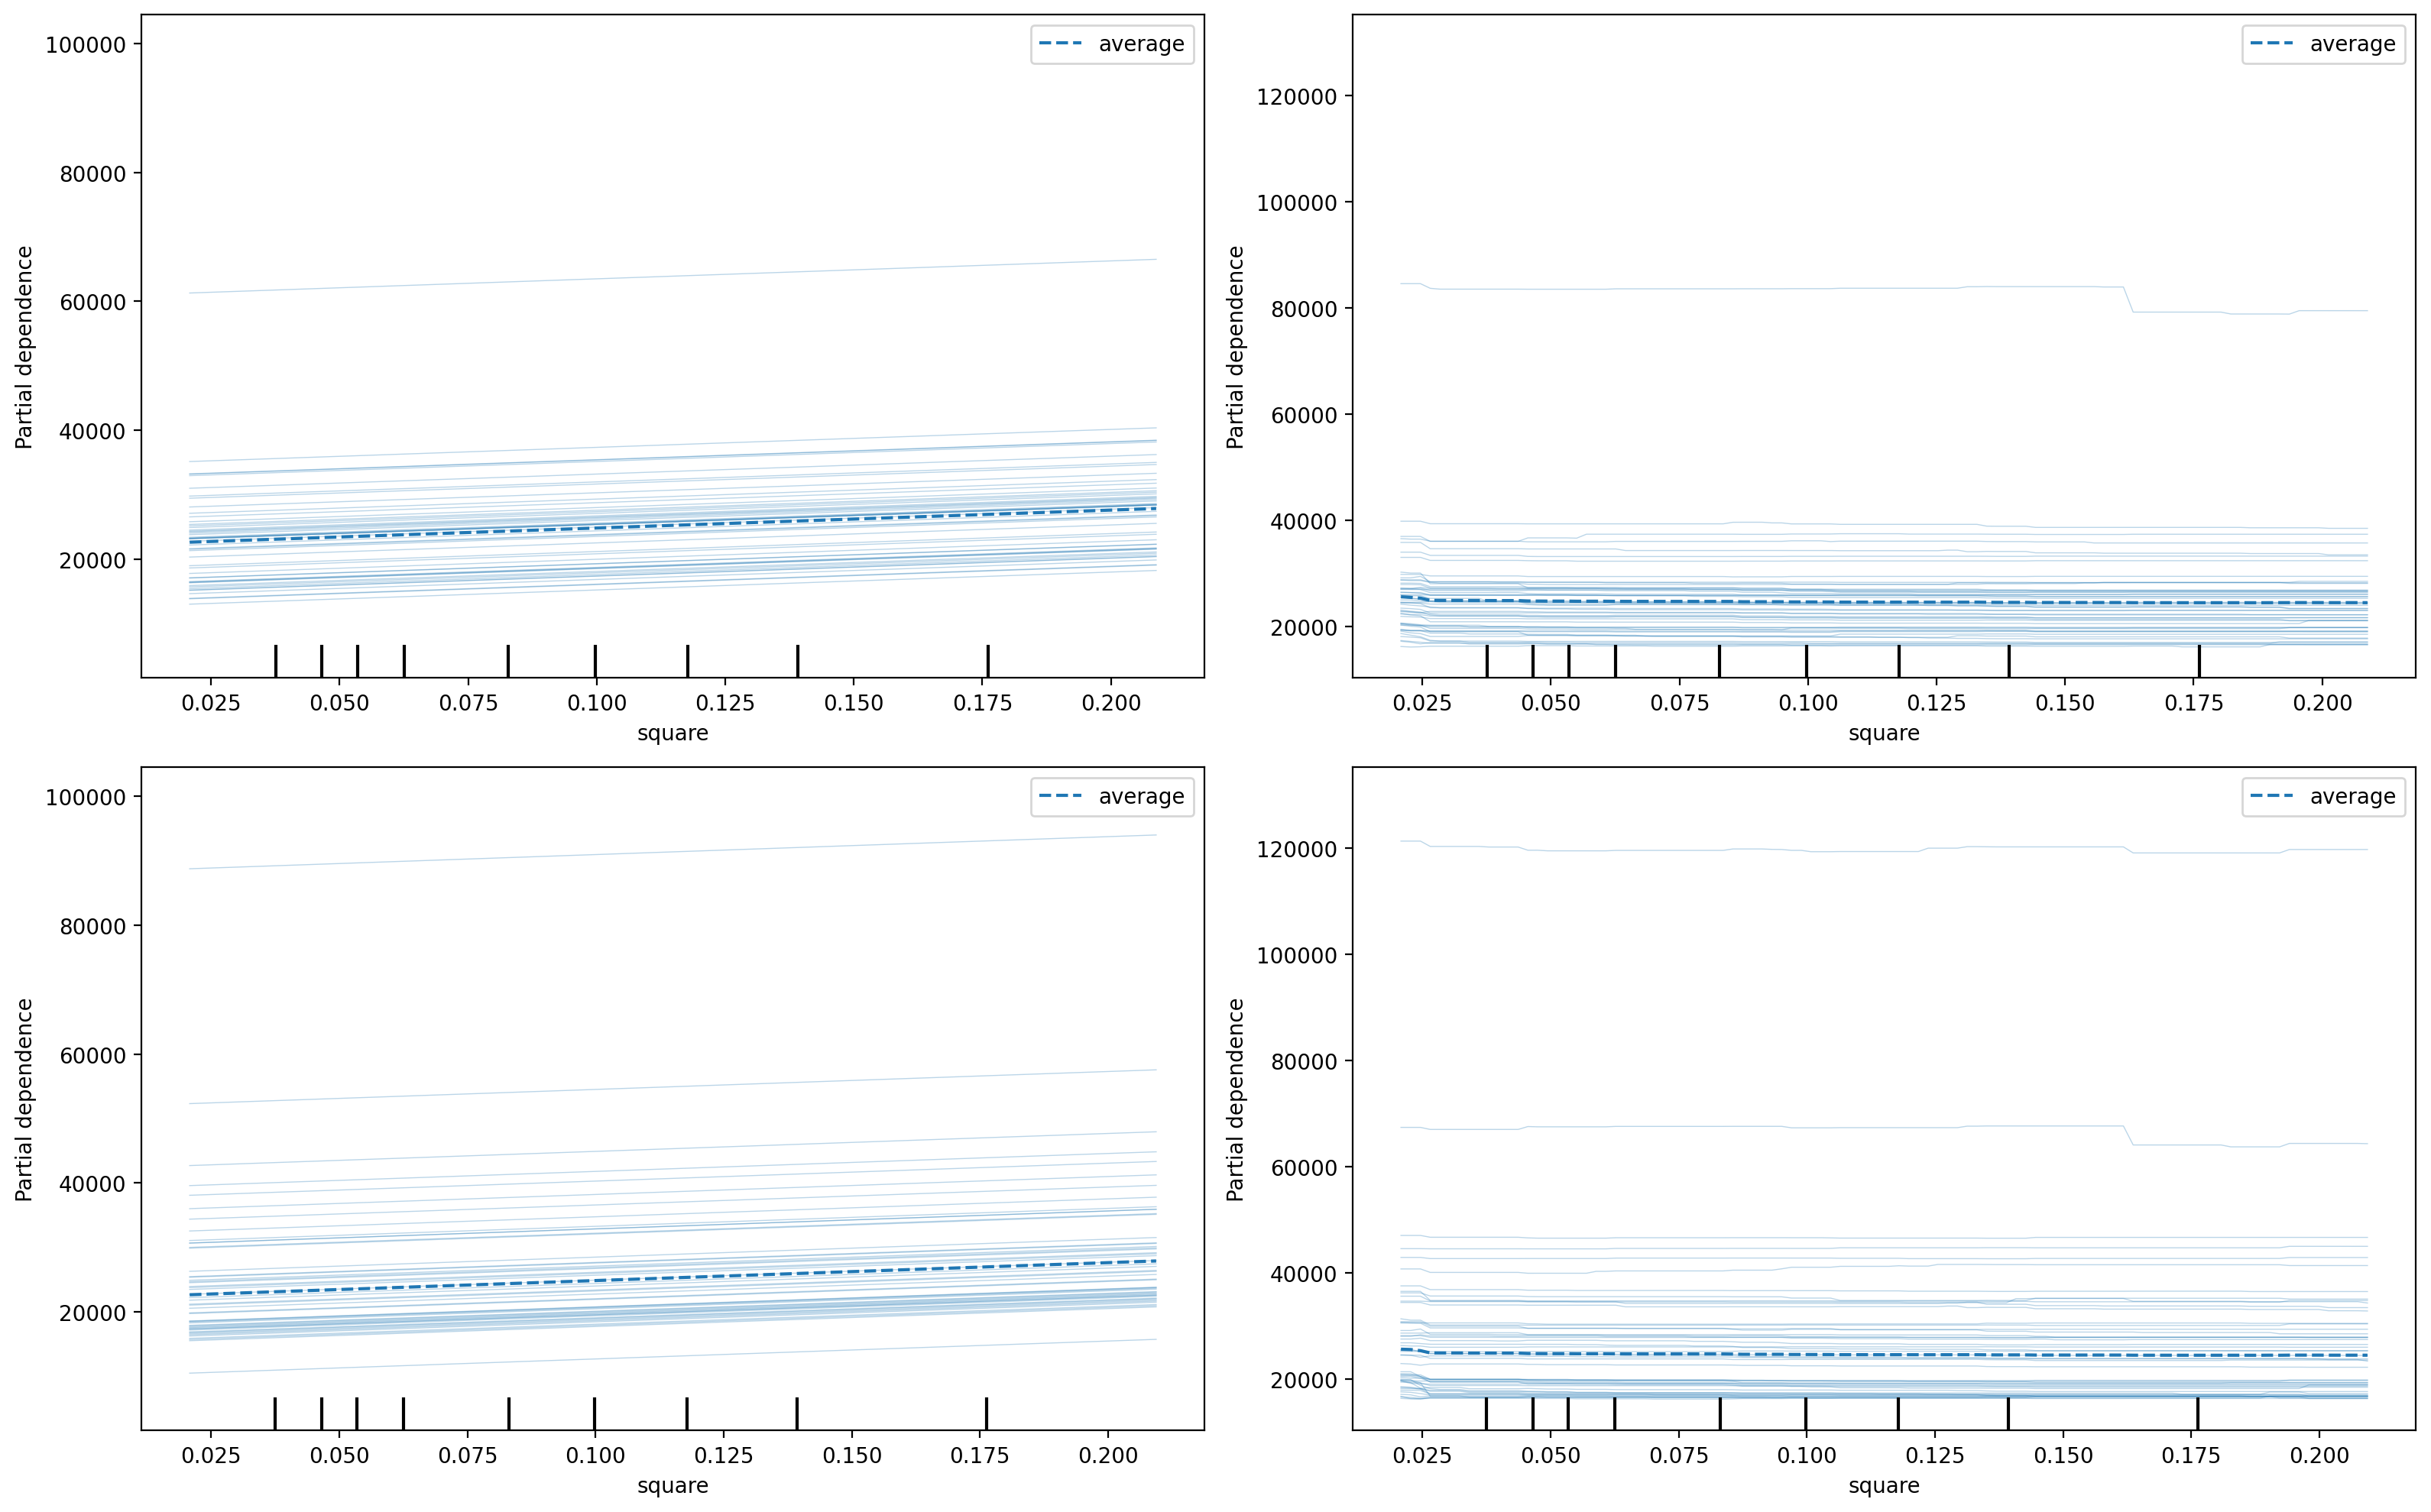

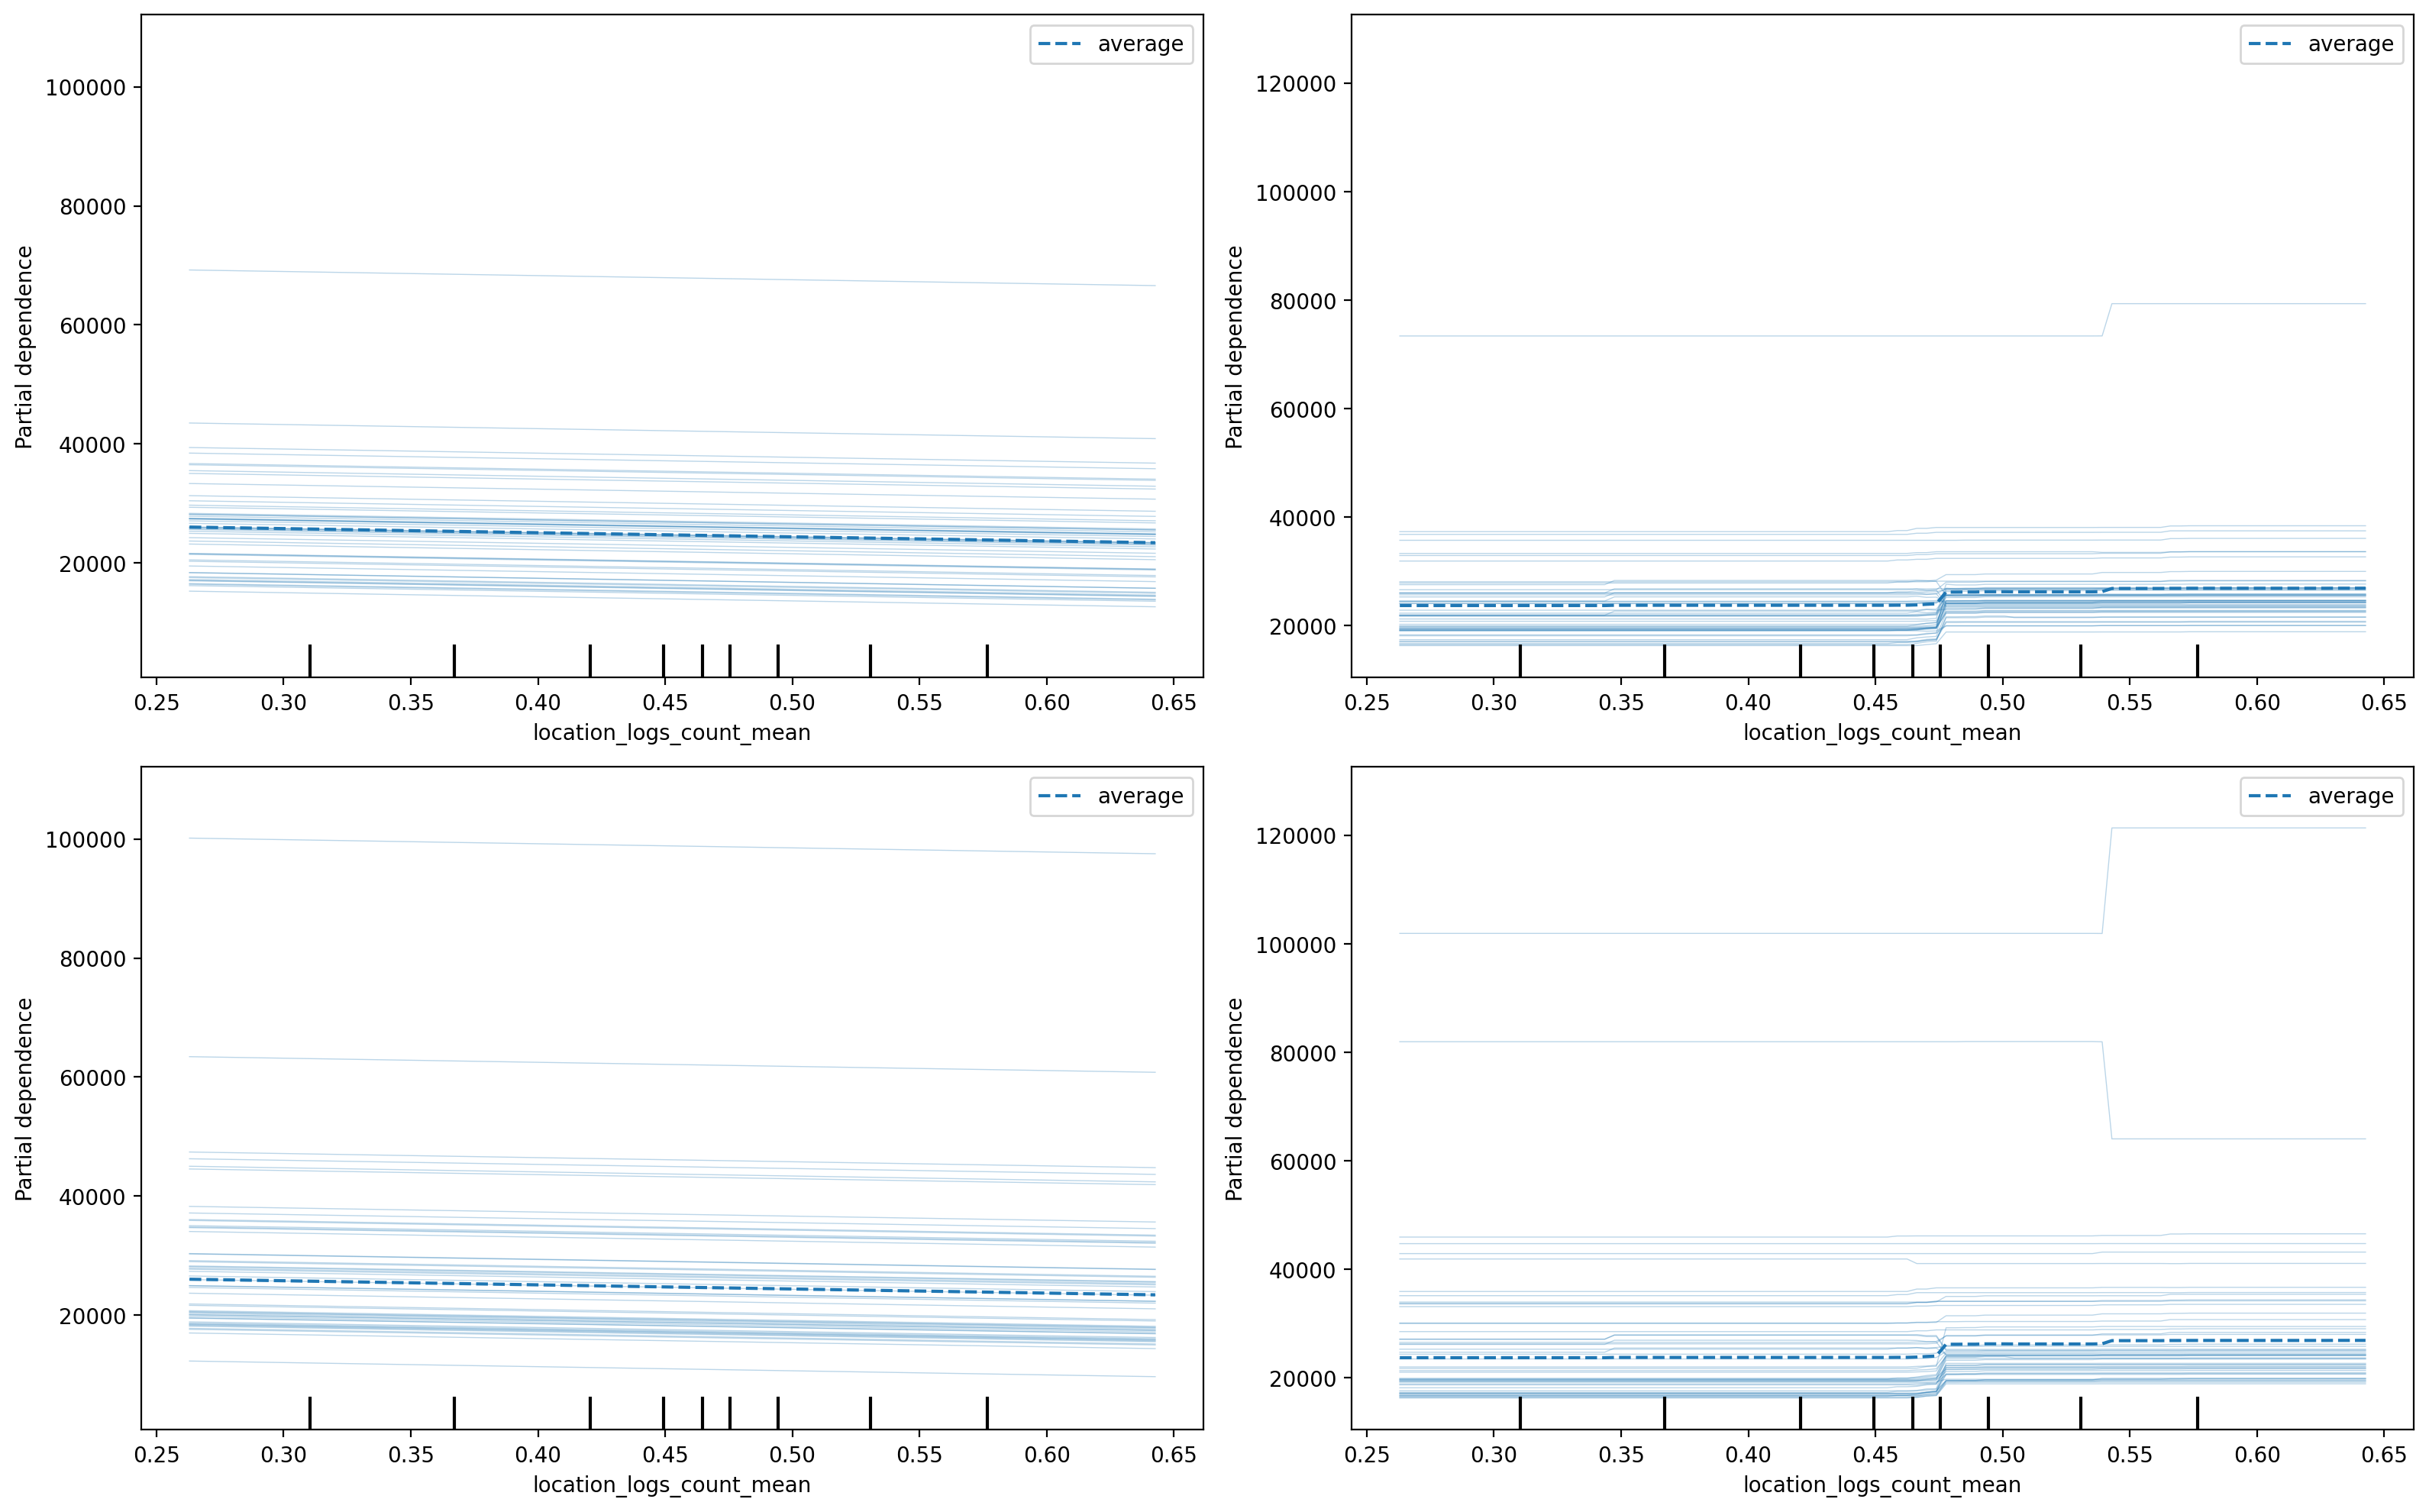

In [23]:
for feature in analysis_features:
    lo, hi = X_train[feature].min(), X_train[feature].max()
    span = hi - lo
    X_aug = X_test.copy()
    extra = X_test.sample(6, random_state=RANDOM_STATE).copy()
    extra[feature] = np.linspace(lo - 0.2 * span, hi + 0.2 * span, len(extra))
    X_aug = pd.concat([X_aug, extra])
    X_aug_scaled = pd.DataFrame(minmax_scaler.transform(X_aug), columns=feature_names, index=X_aug.index)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    PartialDependenceDisplay.from_estimator(lin_minmax, X_test_minmax, [feature], kind='both', subsample=50, random_state=RANDOM_STATE, ax=axes[0, 0])
    PartialDependenceDisplay.from_estimator(gbr_minmax, X_test_minmax, [feature], kind='both', subsample=50, random_state=RANDOM_STATE, ax=axes[0, 1])
    PartialDependenceDisplay.from_estimator(lin_minmax, X_aug_scaled, [feature], kind='both', subsample=50, random_state=RANDOM_STATE, ax=axes[1, 0])
    PartialDependenceDisplay.from_estimator(gbr_minmax, X_aug_scaled, [feature], kind='both', subsample=50, random_state=RANDOM_STATE, ax=axes[1, 1])
    plt.tight_layout()


In [24]:
print('Вывод: линейная модель экстраполирует за диапазон, а бустинг чаще выходит на плато.')


Вывод: линейная модель экстраполирует за диапазон, а бустинг чаще выходит на плато.


## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

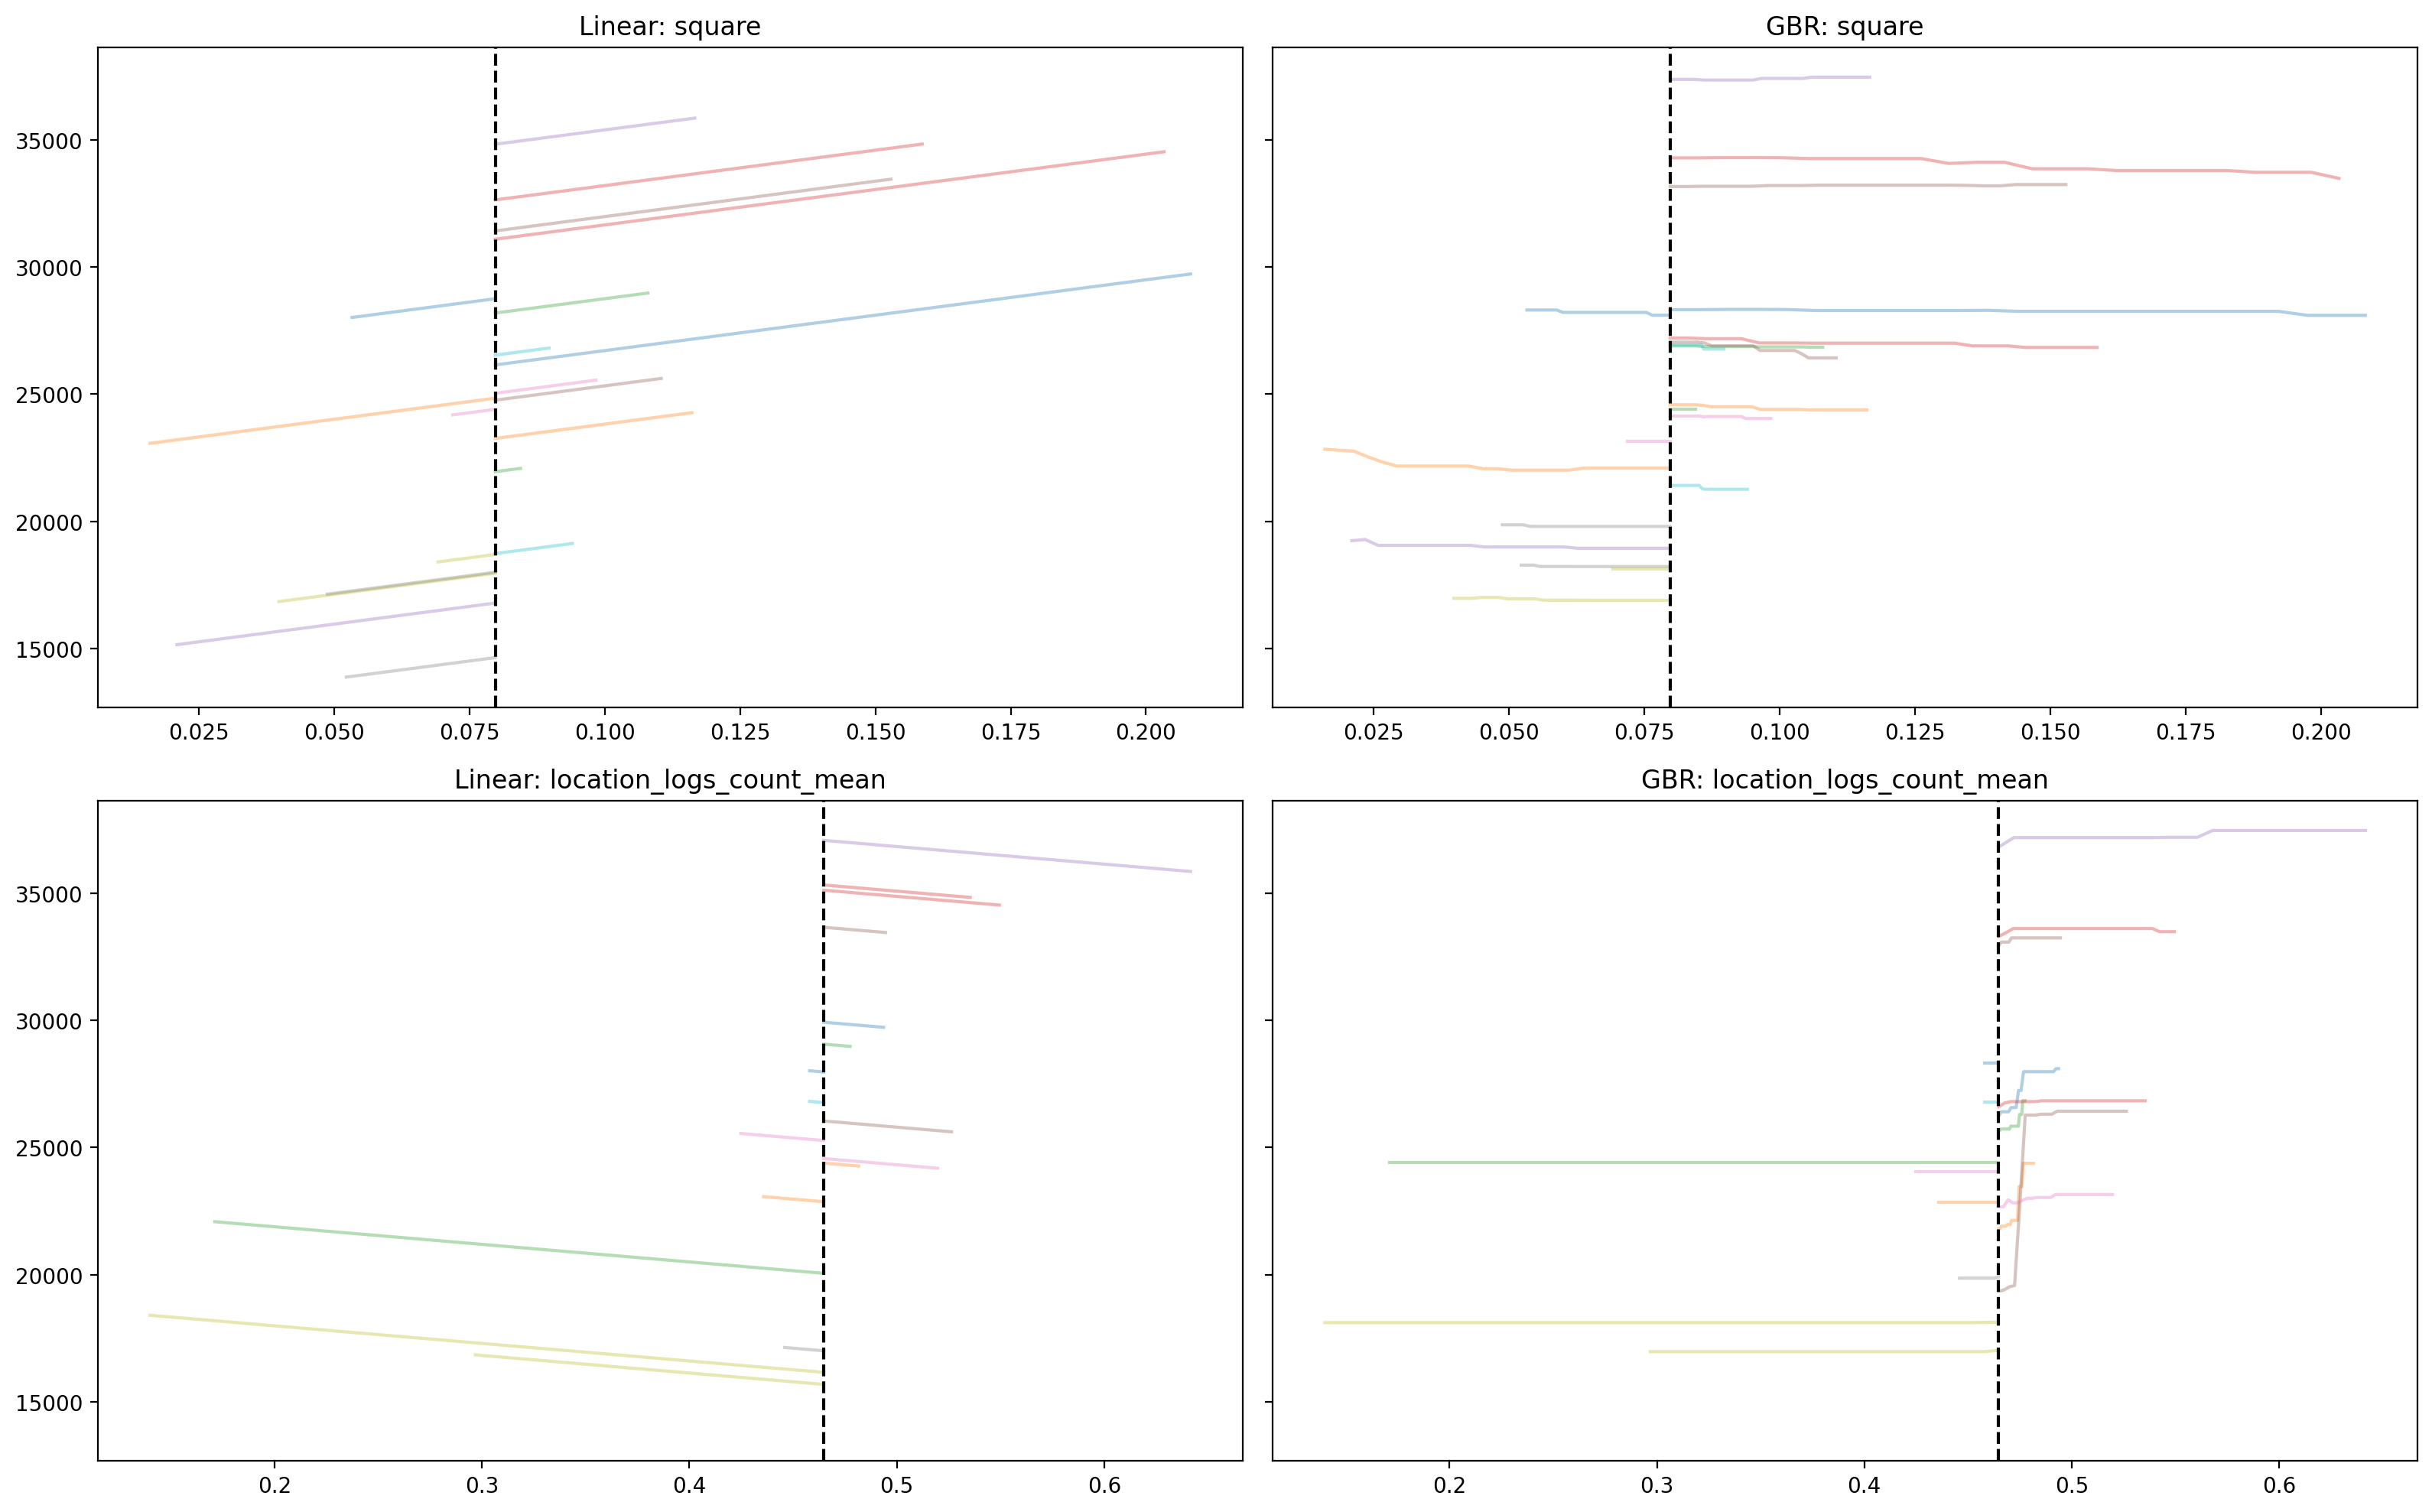

In [25]:
def plot_paths(model, X_points, feature, base_value, ax, title, n_steps=25):
    for _, row in X_points.iterrows():
        grid = np.linspace(row[feature], base_value, n_steps)
        preds = []
        for value in grid:
            row_mod = row.copy()
            row_mod[feature] = value
            preds.append(model.predict(row_mod.to_frame().T)[0])
        ax.plot(grid, preds, alpha=0.35)
    ax.axvline(base_value, color='black', linestyle='--')
    ax.set_title(title)

sample_points = X_test_minmax.sample(20, random_state=RANDOM_STATE)
base_values = X_train_minmax.median()
fig, axes = plt.subplots(len(analysis_features), 2, figsize=(16, 10), sharey='row')
for i, feature in enumerate(analysis_features):
    plot_paths(lin_minmax, sample_points, feature, base_values[feature], axes[i, 0], f'Linear: {feature}')
    plot_paths(gbr_minmax, sample_points, feature, base_values[feature], axes[i, 1], f'GBR: {feature}')
plt.tight_layout()


In [26]:
print('Вывод: у линейной модели траектории почти прямые, у бустинга они нелинейные и ступенчатые.')


Вывод: у линейной модели траектории почти прямые, у бустинга они нелинейные и ступенчатые.


## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


Средняя ширина CI для linear: 0.0
Средняя ширина CI для gbr: 42.094


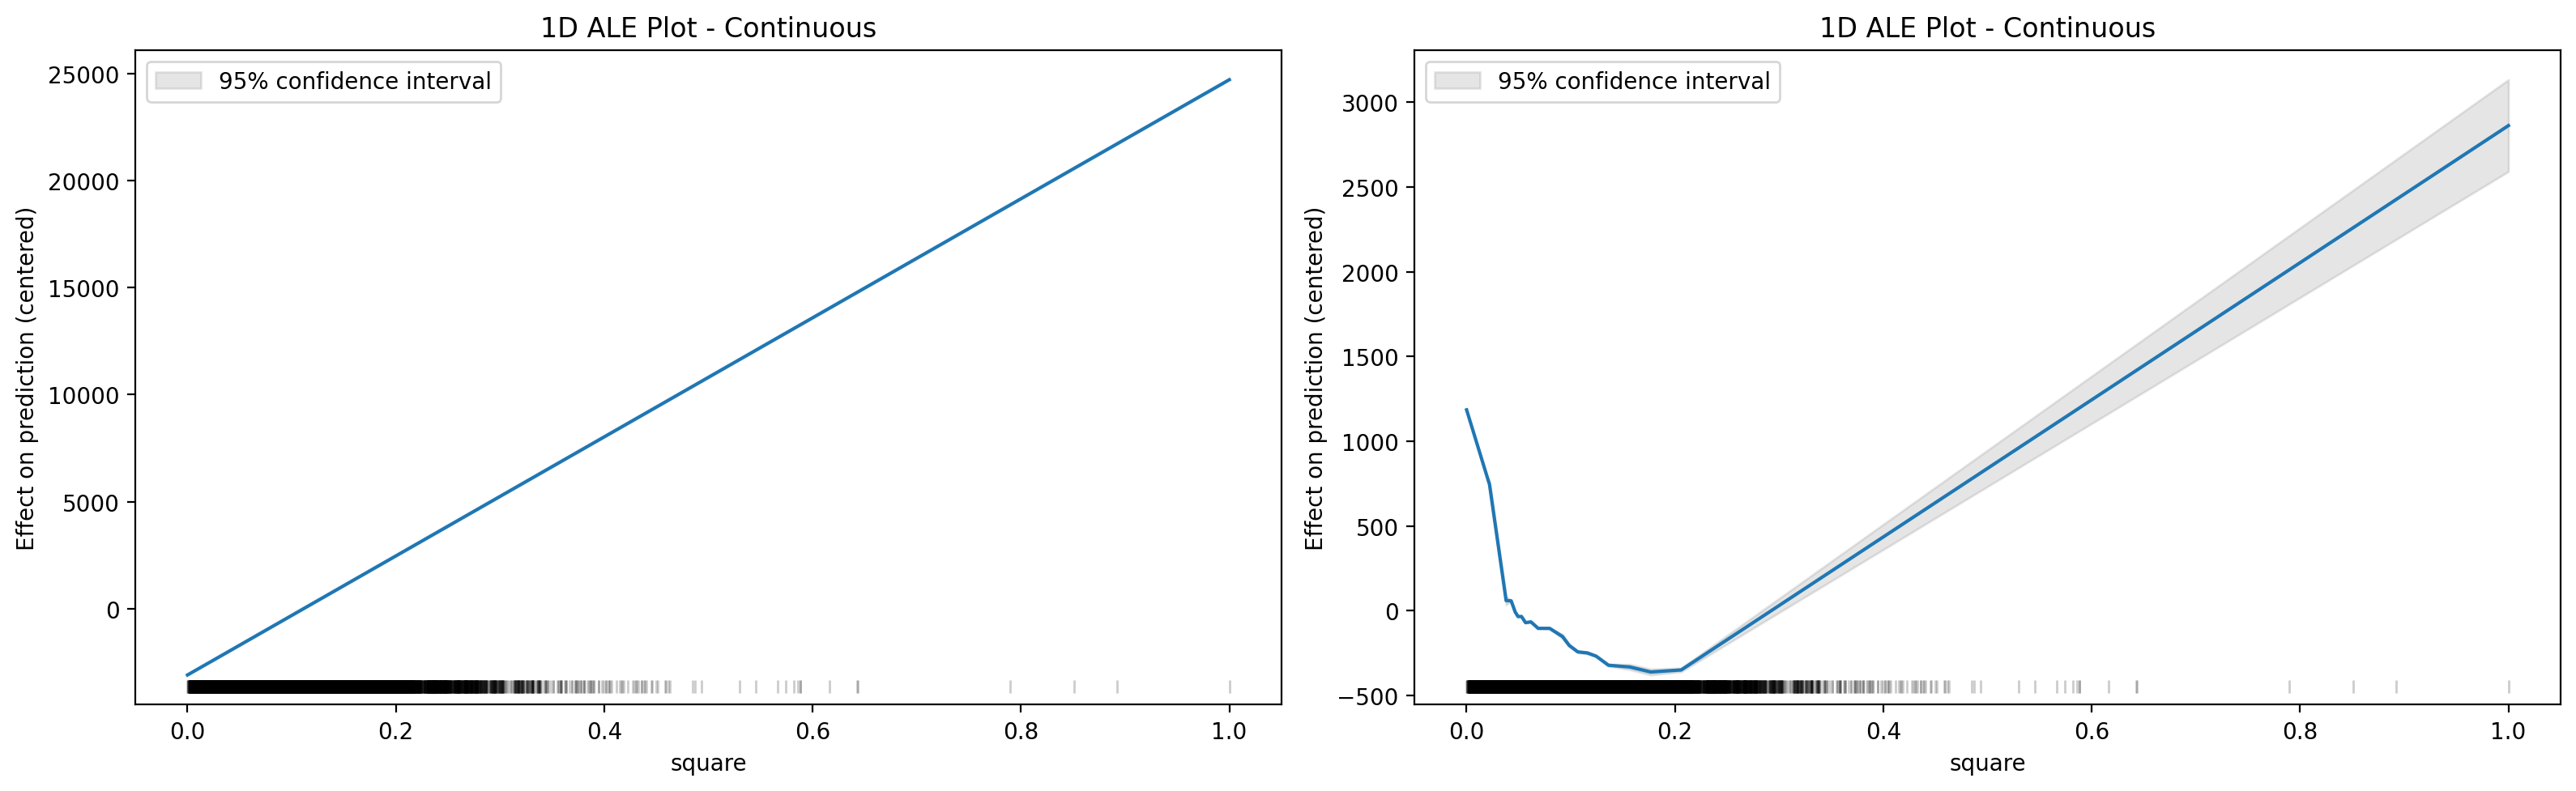

In [27]:
from PyALE import ale

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ale_linear = ale(X=X_train_minmax, model=lin_minmax, feature=['square'], grid_size=20, include_CI=True, plot=True, fig=fig, ax=axes[0])
ale_gbr = ale(X=X_train_minmax, model=gbr_minmax, feature=['square'], grid_size=20, include_CI=True, plot=True, fig=fig, ax=axes[1])
plt.tight_layout()
print('Средняя ширина CI для linear:', round((ale_linear['upperCI_95%'] - ale_linear['lowerCI_95%']).dropna().mean(), 4))
print('Средняя ширина CI для gbr:', round((ale_gbr['upperCI_95%'] - ale_gbr['lowerCI_95%']).dropna().mean(), 4))


In [28]:
print('Вывод: у бустинга ALE обычно рванее и доверительные интервалы шире.')


Вывод: у бустинга ALE обычно рванее и доверительные интервалы шире.


## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



,feature,importance_mean,importance_std
72,location_public_transport_platform_w_mean_distance,18.293062,0.132192
59,location_highway_crossing_w_mean_distance,18.010002,0.130207
37,location_std_levels_mean,0.996078,0.006176
47,location_shop_other_w_mean_distance,0.932945,0.005498
56,location_shop_product_w_mean_distance,0.280169,0.002038


,feature,importance_mean,importance_std
79,class_cat,0.152326,0.002528
7,location_logs_count_mean,0.049204,0.001109
60,location_public_transport_stop_position_cnt,0.022132,0.000202
1,district_cat,0.016297,0.000369
31,location_town_w_mean_distance,0.015321,0.000263


,feature,importance_mean,importance_std
72,location_public_transport_platform_w_mean_distance,18.428469,0.303727
59,location_highway_crossing_w_mean_distance,18.144193,0.299156
37,location_std_levels_mean,1.009457,0.019261
47,location_shop_other_w_mean_distance,0.945478,0.018675
56,location_shop_product_w_mean_distance,0.282363,0.004702


,feature,importance_mean,importance_std
79,class_cat,0.152086,0.002193
7,location_logs_count_mean,0.048501,0.001009
60,location_public_transport_stop_position_cnt,0.022021,0.000531
1,district_cat,0.016378,0.000467
31,location_town_w_mean_distance,0.015283,0.000266


,feature,importance_mean,importance_std
72,location_public_transport_platform_w_mean_distance,18.470946,0.335072
59,location_highway_crossing_w_mean_distance,18.186030,0.330194
37,location_std_levels_mean,1.011270,0.021178
47,location_shop_other_w_mean_distance,0.947145,0.020700
56,location_shop_product_w_mean_distance,0.282989,0.005207


,feature,importance_mean,importance_std
79,class_cat,0.152282,0.002360
7,location_logs_count_mean,0.048211,0.000976
60,location_public_transport_stop_position_cnt,0.021982,0.000538
1,district_cat,0.016417,0.000421
31,location_town_w_mean_distance,0.015250,0.000360


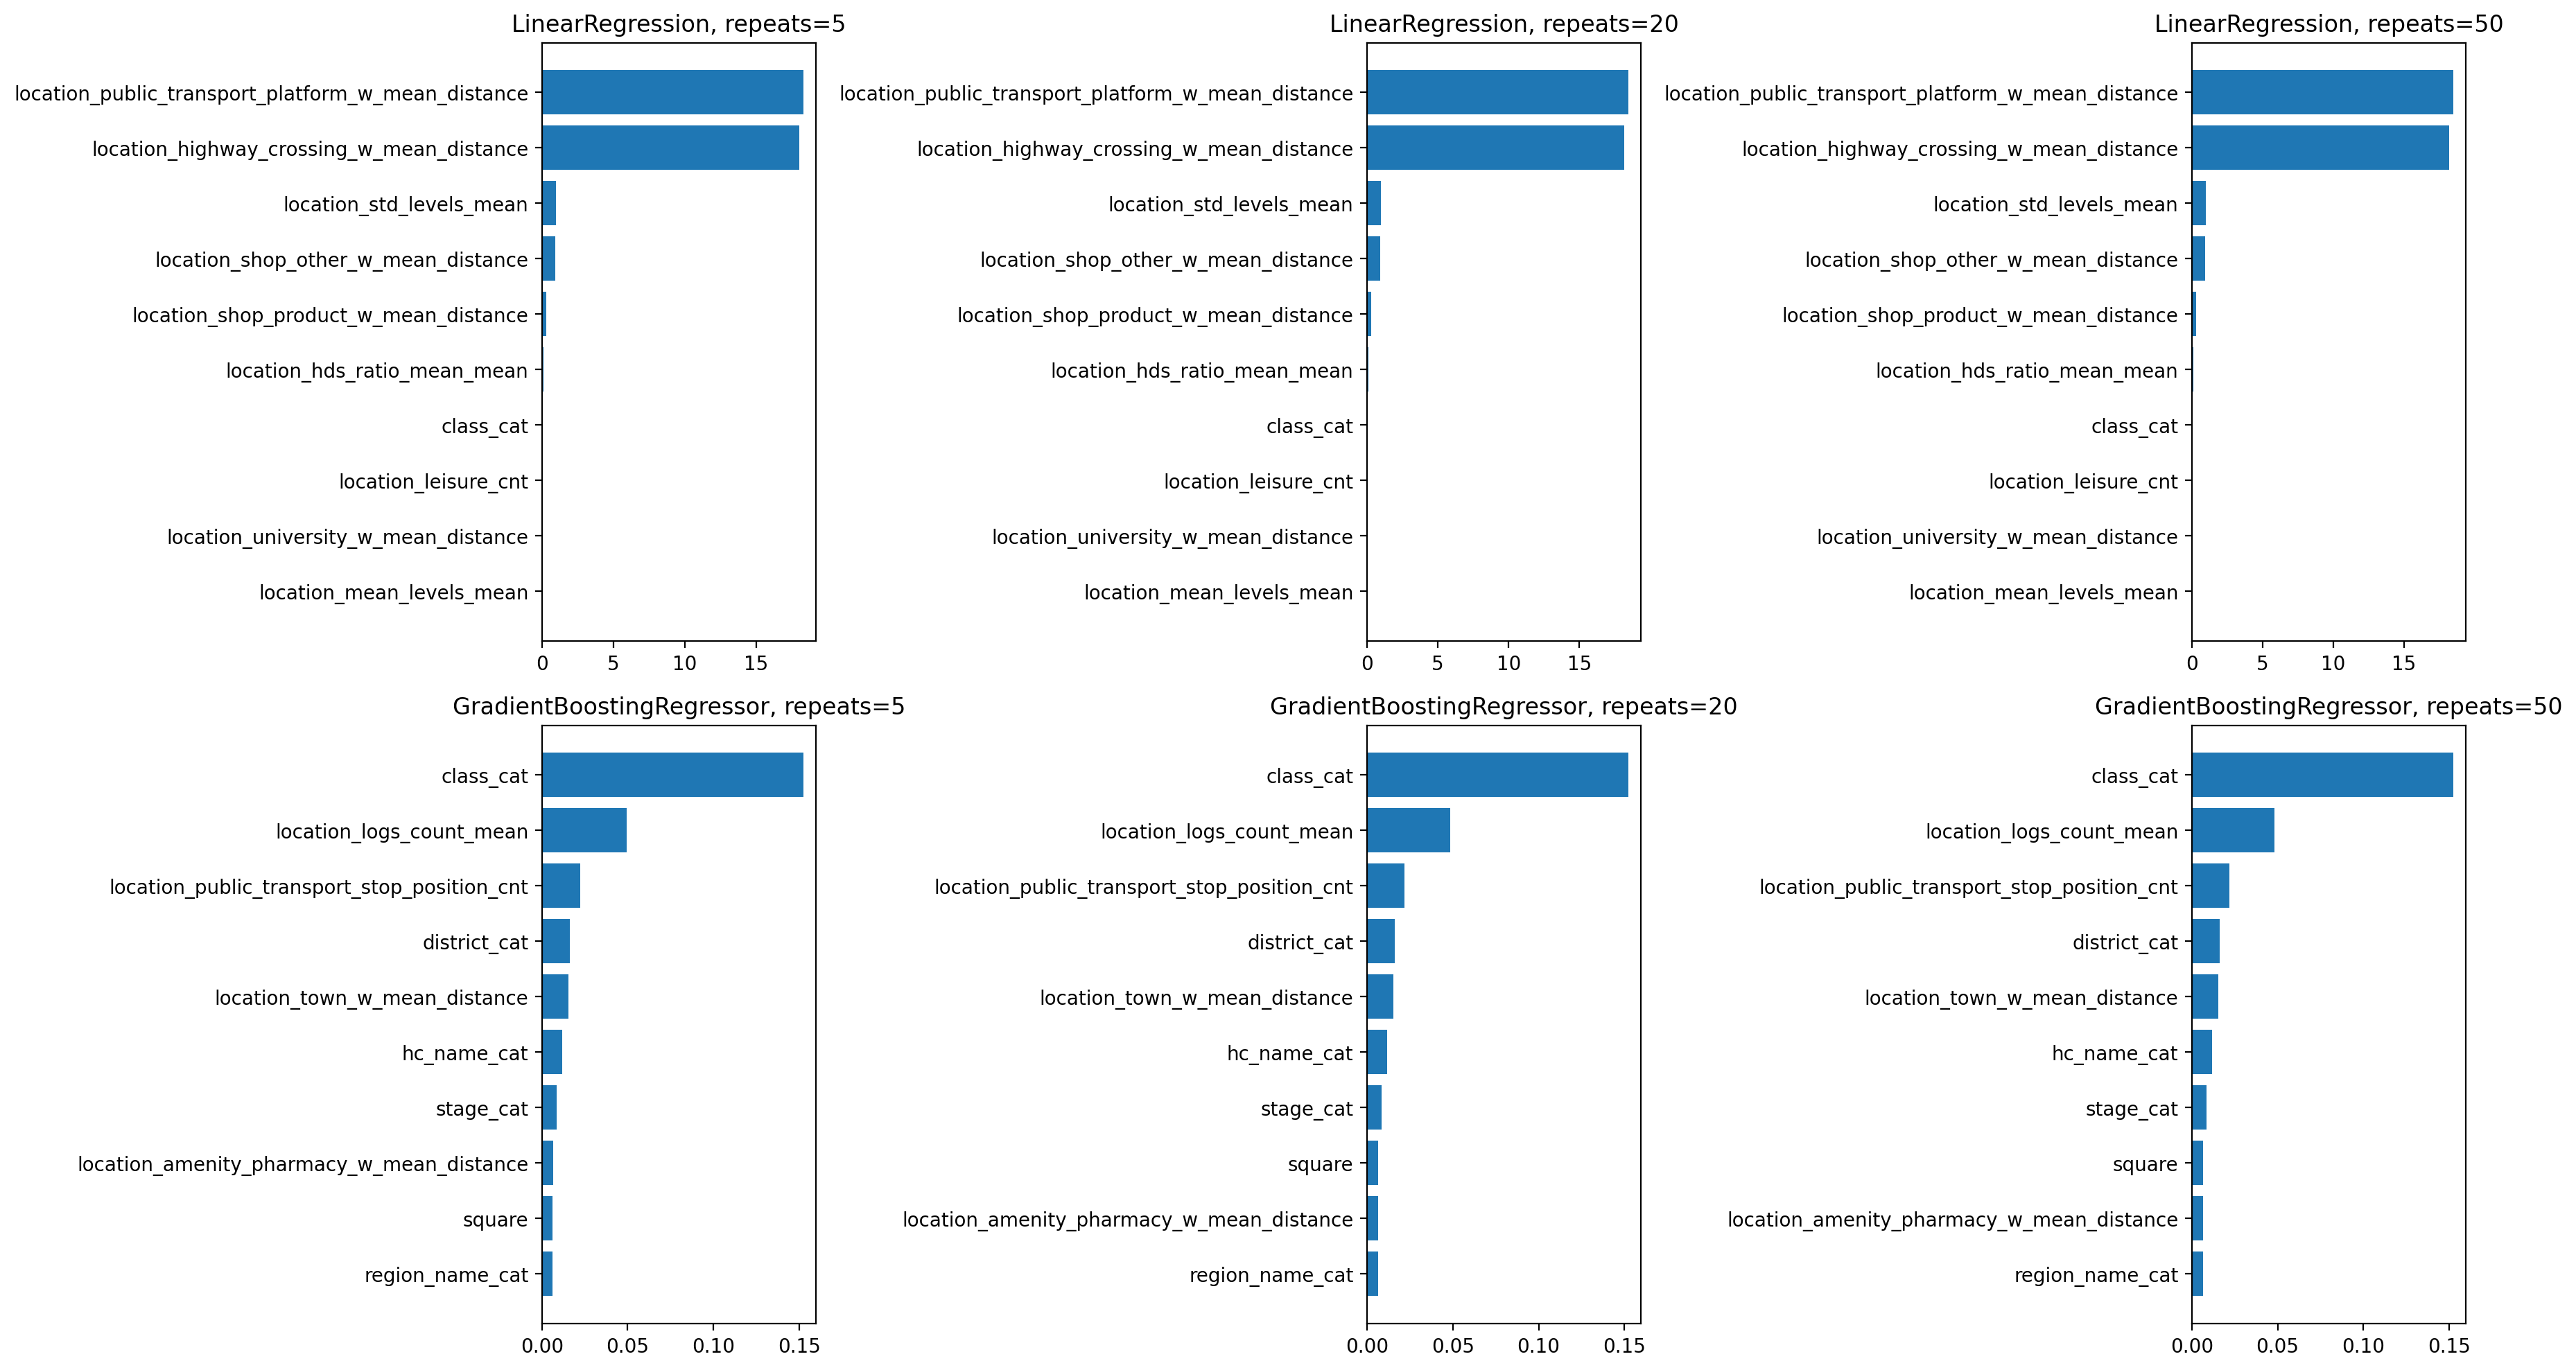

In [29]:
repeat_values = [5, 20, 50]
permutation_results = {}
for repeats in repeat_values:
    permutation_results[repeats] = {}
    for model_name, model in [('LinearRegression', lin_minmax), ('GradientBoostingRegressor', gbr_minmax)]:
        result = permutation_importance(model, X_test_minmax, y_test, scoring='neg_mean_absolute_percentage_error', n_repeats=repeats, random_state=RANDOM_STATE, n_jobs=1)
        df_imp = pd.DataFrame({'feature': feature_names, 'importance_mean': result.importances_mean, 'importance_std': result.importances_std}).sort_values('importance_mean', ascending=False)
        permutation_results[repeats][model_name] = df_imp
        display(df_imp.head(5).style.format({'importance_mean': '{:.6f}', 'importance_std': '{:.6f}'}))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, repeats in enumerate(repeat_values):
    for row, model_name in enumerate(['LinearRegression', 'GradientBoostingRegressor']):
        top_df = permutation_results[repeats][model_name].head(10).sort_values('importance_mean')
        axes[row, col].barh(top_df['feature'], top_df['importance_mean'])
        axes[row, col].set_title(f'{model_name}, repeats={repeats}')
plt.tight_layout()


In [30]:
print('Вывод: при росте числа перестановок ranking важностей стабилизируется.')


Вывод: при росте числа перестановок ranking важностей стабилизируется.


## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

In [31]:
gbr_base_mape = mean_absolute_percentage_error(y_test, gbr_minmax.predict(X_test_minmax))
median_scaled = X_train_minmax.median()
beta_values = [0.25, 0.5, 0.75, 1.0]
beta_importances = {}
for beta in beta_values:
    rows = []
    for feature in numeric_features:
        X_mod = X_test_minmax.copy()
        X_mod[feature] = (1 - beta) * X_mod[feature] + beta * median_scaled[feature]
        rows.append({'feature': feature, 'delta_mape': mean_absolute_percentage_error(y_test, gbr_minmax.predict(X_mod)) - gbr_base_mape})
    beta_importances[beta] = pd.DataFrame(rows).sort_values('delta_mape', ascending=False)
    display(beta_importances[beta].head(5).style.format({'delta_mape': '{:.6f}'}))


,feature,delta_mape
79,class_cat,0.009537
31,location_town_w_mean_distance,0.009030
60,location_public_transport_stop_position_cnt,0.003136
77,hc_name_cat,0.002548
1,district_cat,0.002325


,feature,delta_mape
79,class_cat,0.009537
31,location_town_w_mean_distance,0.009048
0,region_name_cat,0.007124
80,stage_cat,0.004915
1,district_cat,0.004781


,feature,delta_mape
79,class_cat,0.050083
31,location_town_w_mean_distance,0.009614
7,location_logs_count_mean,0.007196
0,region_name_cat,0.007124
70,location_amenity_pharmacy_w_mean_distance,0.007036


,feature,delta_mape
79,class_cat,0.050083
7,location_logs_count_mean,0.023531
31,location_town_w_mean_distance,0.009614
0,region_name_cat,0.007124
75,location_leisure_w_mean_distance,0.007118


Базовая MAPE бустинга: 0.0399
Совпадающие top-10 признаки: ['class_cat', 'district_cat', 'hc_name_cat', 'location_amenity_pharmacy_w_mean_distance', 'location_logs_count_mean', 'location_public_transport_stop_position_cnt', 'location_town_w_mean_distance', 'region_name_cat']


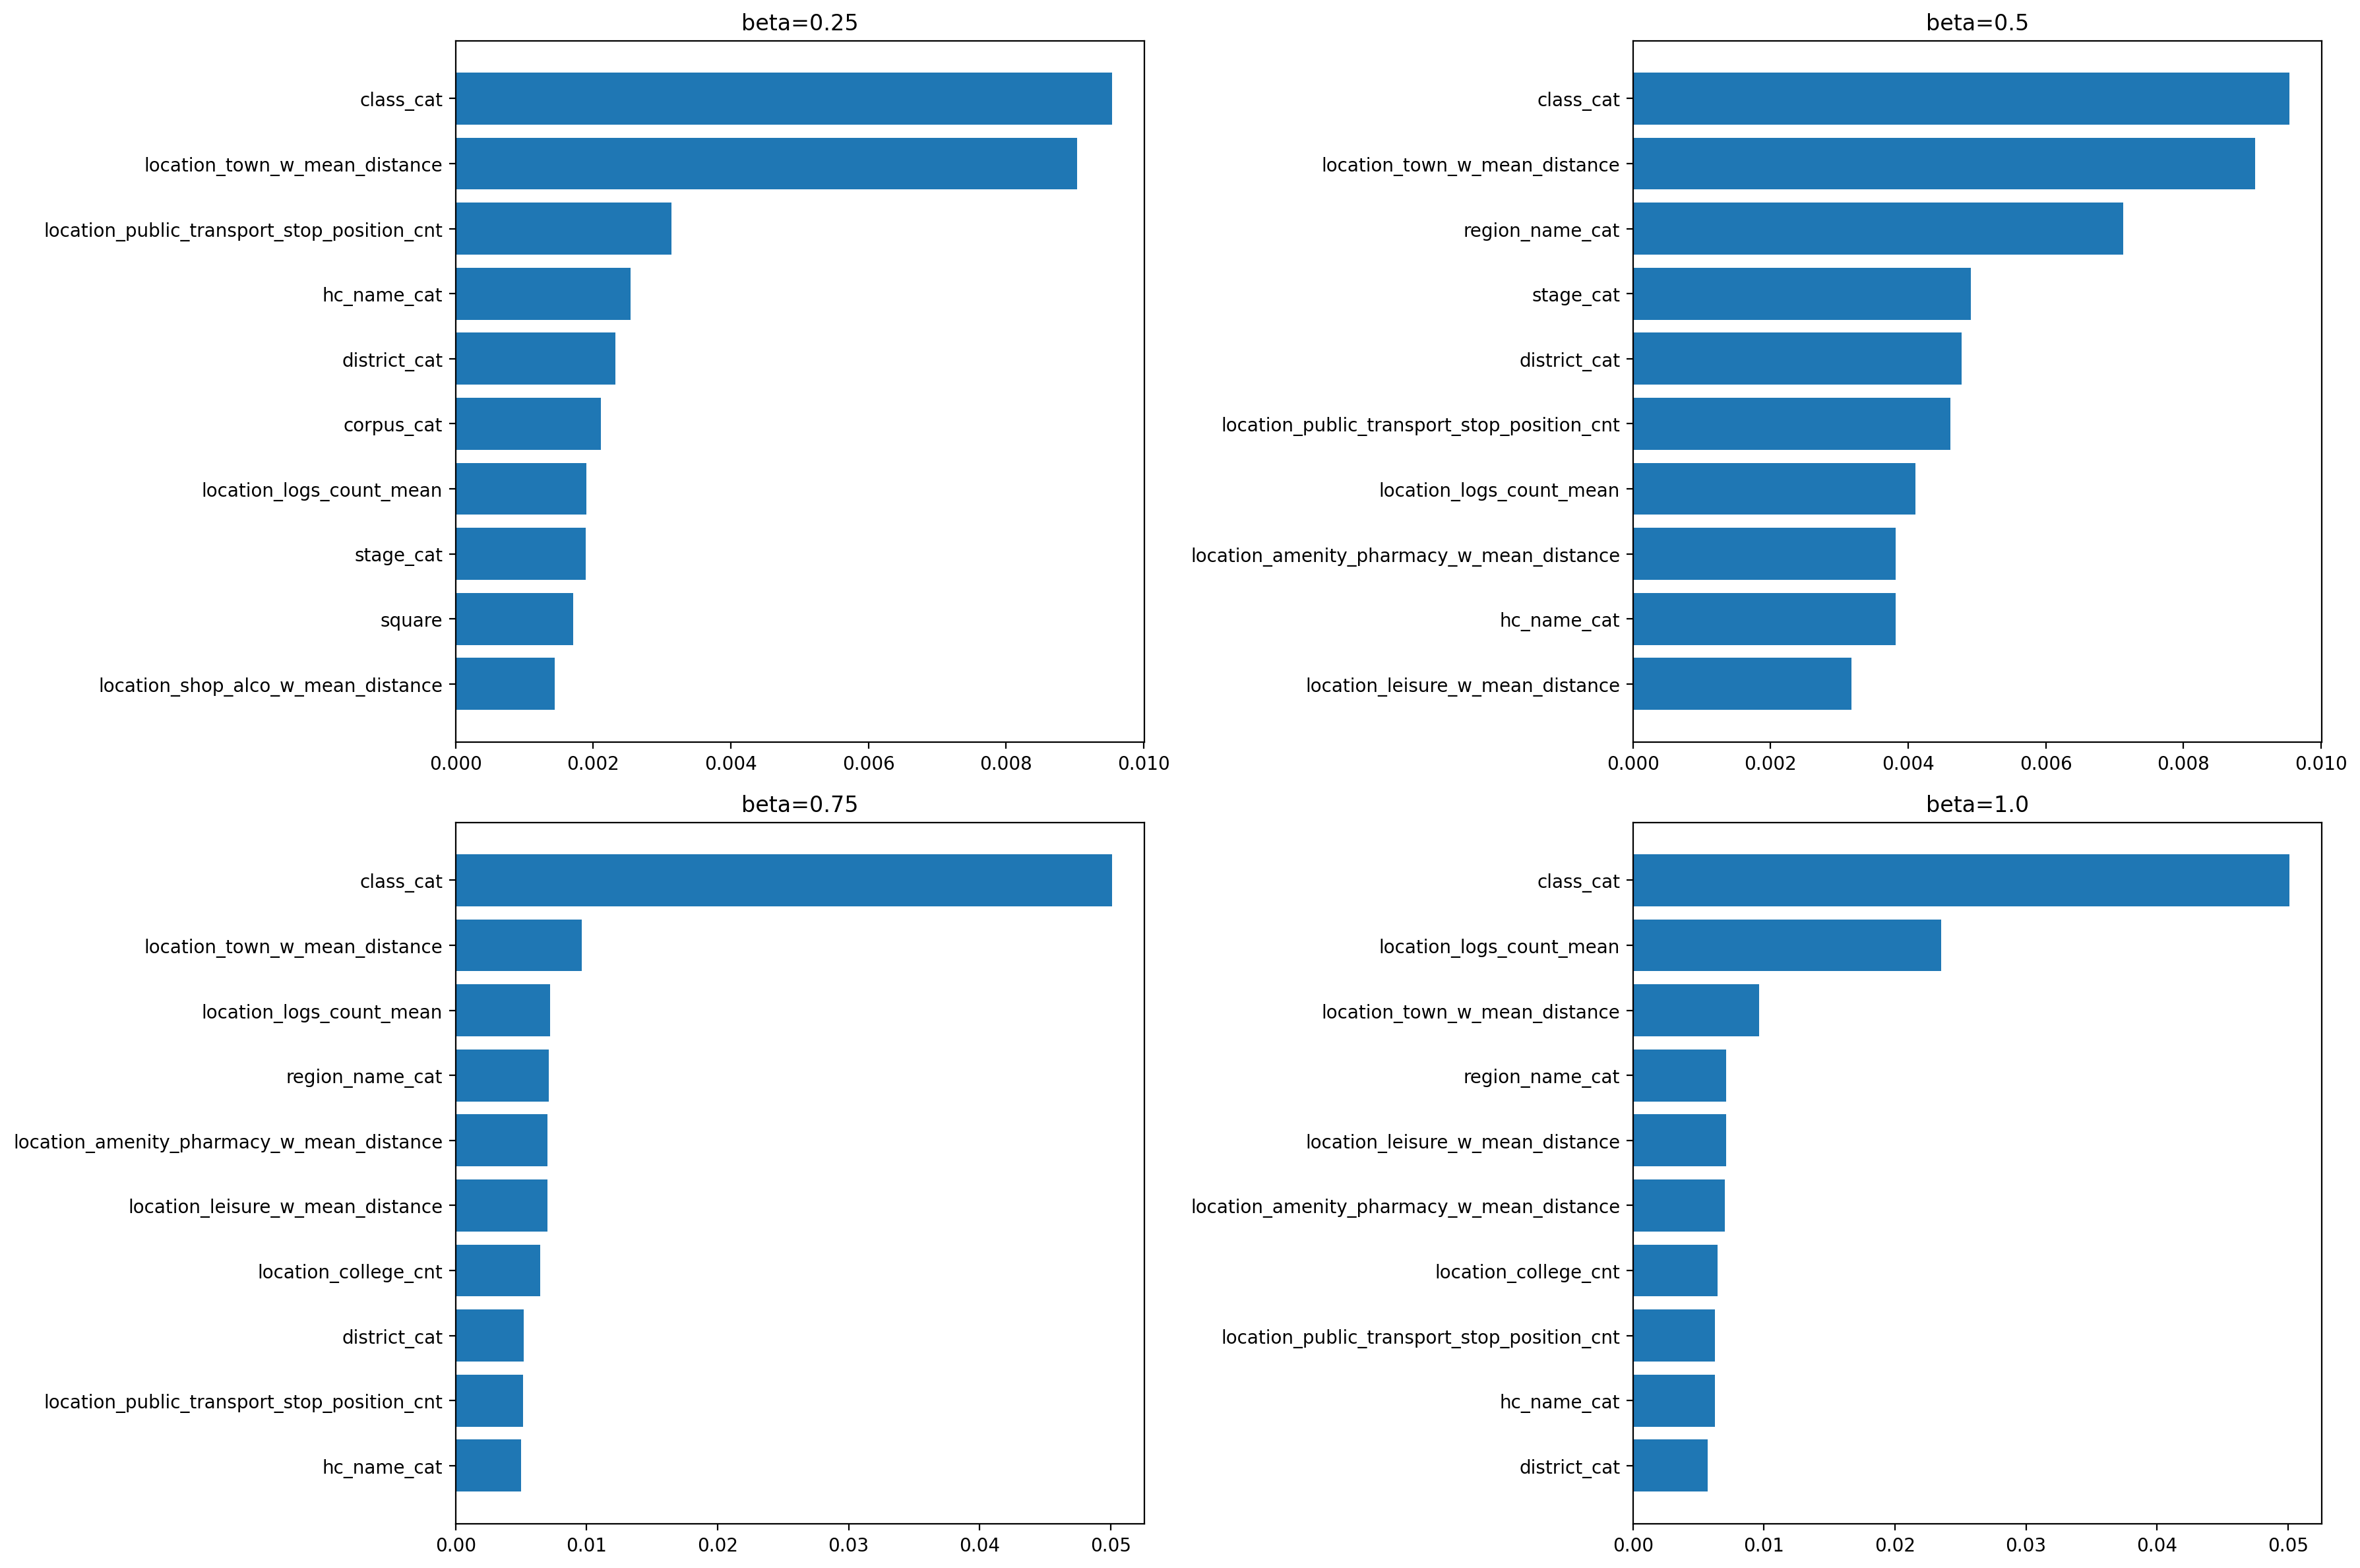

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, beta in zip(axes.ravel(), beta_values):
    top_df = beta_importances[beta].head(10).sort_values('delta_mape')
    ax.barh(top_df['feature'], top_df['delta_mape'])
    ax.set_title(f'beta={beta}')
plt.tight_layout()
shared = sorted(set(permutation_results[50]['GradientBoostingRegressor'].head(10)['feature']) & set(beta_importances[1.0].head(10)['feature']))
print('Базовая MAPE бустинга:', round(gbr_base_mape, 4))
print('Совпадающие top-10 признаки:', shared)


In [33]:
print('Вывод: при росте beta важности увеличиваются, но ranking не полностью совпадает с permutation importance.')


Вывод: при росте beta важности увеличиваются, но ranking не полностью совпадает с permutation importance.


#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



,setting,score,top_features
0,num_samples=500,0.346942,"[class_cat, location_public_transport_stop_pos..."
1,num_samples=2000,0.382310,"[class_cat, location_logs_count_mean, location..."
2,num_samples=5000,0.395252,"[class_cat, location_logs_count_mean, location..."


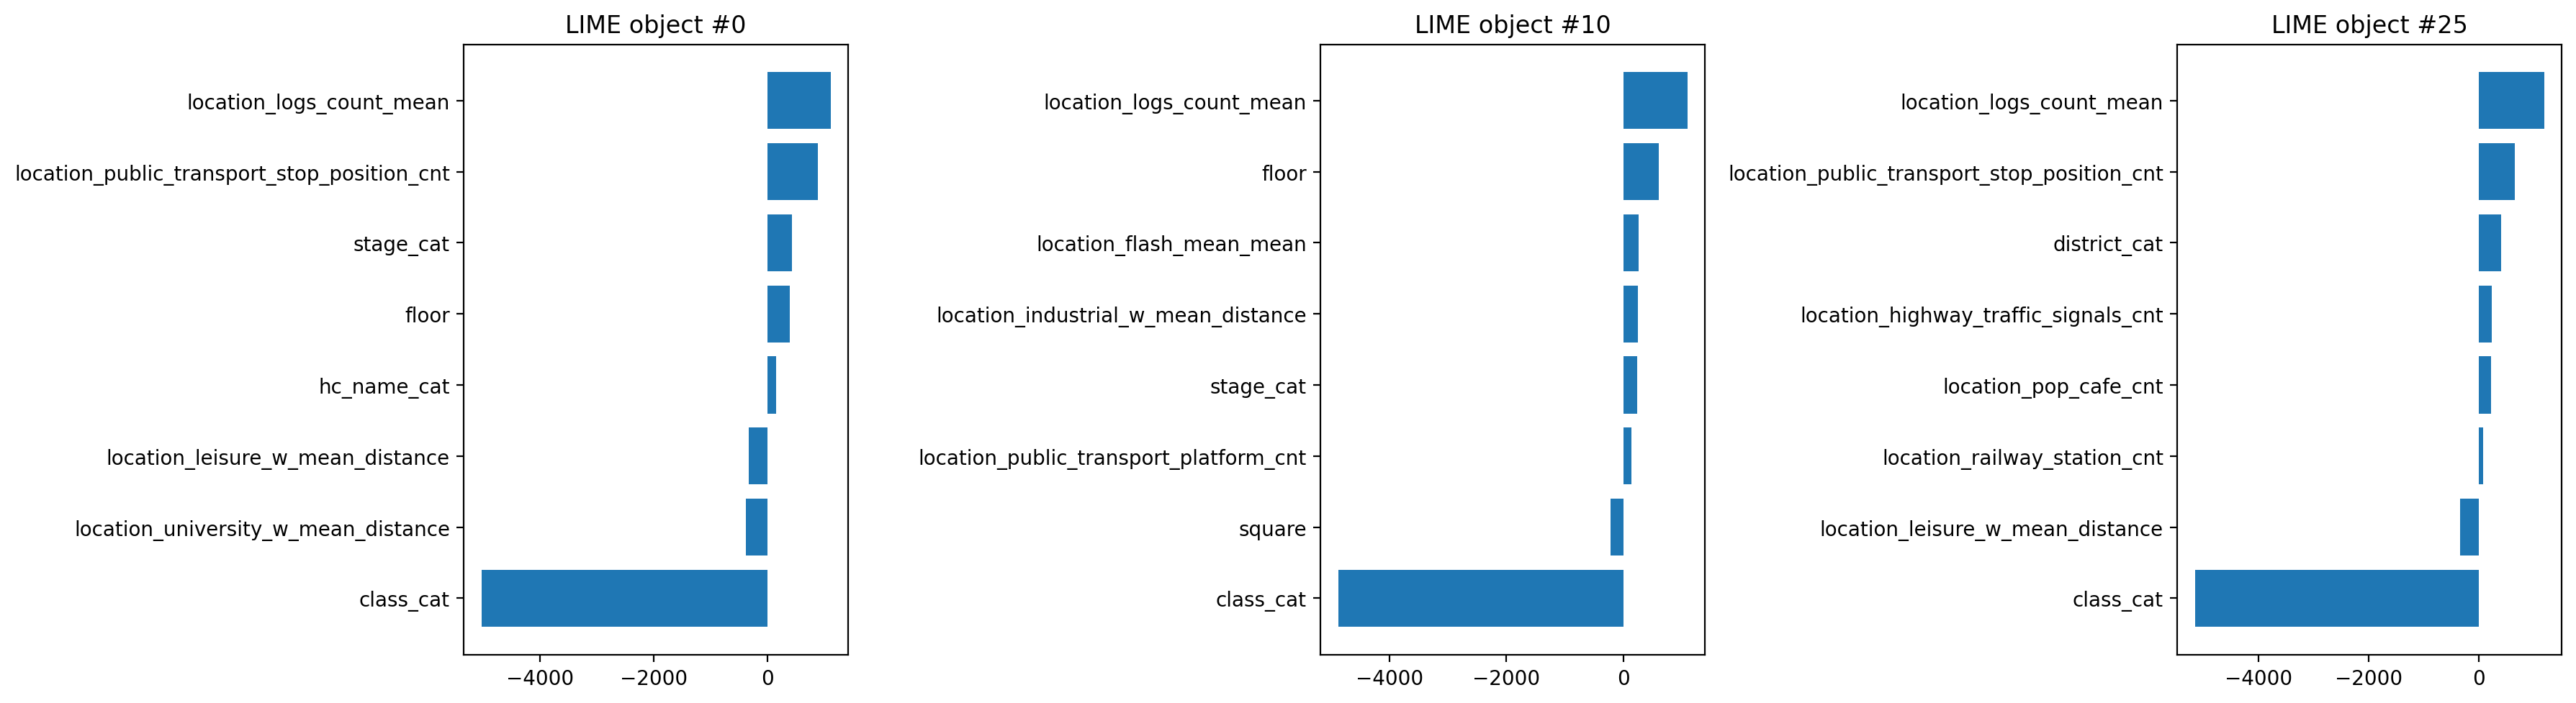

In [34]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(X_train_minmax.values, feature_names=feature_names, mode='regression', discretize_continuous=False, random_state=RANDOM_STATE)
lime_examples = [0, 10, 25]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, idx in zip(axes, lime_examples):
    exp = lime_explainer.explain_instance(X_test_minmax.iloc[idx].values, gbr_minmax.predict, num_features=8, num_samples=2000)
    weights = pd.DataFrame(exp.as_list(), columns=['feature', 'weight']).sort_values('weight')
    ax.barh(weights['feature'], weights['weight'])
    ax.set_title(f'LIME object #{idx}')
plt.tight_layout()

stability_rows = []
for num_samples in [500, 2000, 5000]:
    exp = lime_explainer.explain_instance(X_test_minmax.iloc[0].values, gbr_minmax.predict, num_features=8, num_samples=num_samples)
    stability_rows.append({'setting': f'num_samples={num_samples}', 'score': exp.score, 'top_features': [f for f, _ in exp.as_list()[:5]]})
display(pd.DataFrame(stability_rows))


In [35]:
print('Вывод: при увеличении num_samples объяснение обычно становится стабильнее.')


Вывод: при увеличении num_samples объяснение обычно становится стабильнее.


## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


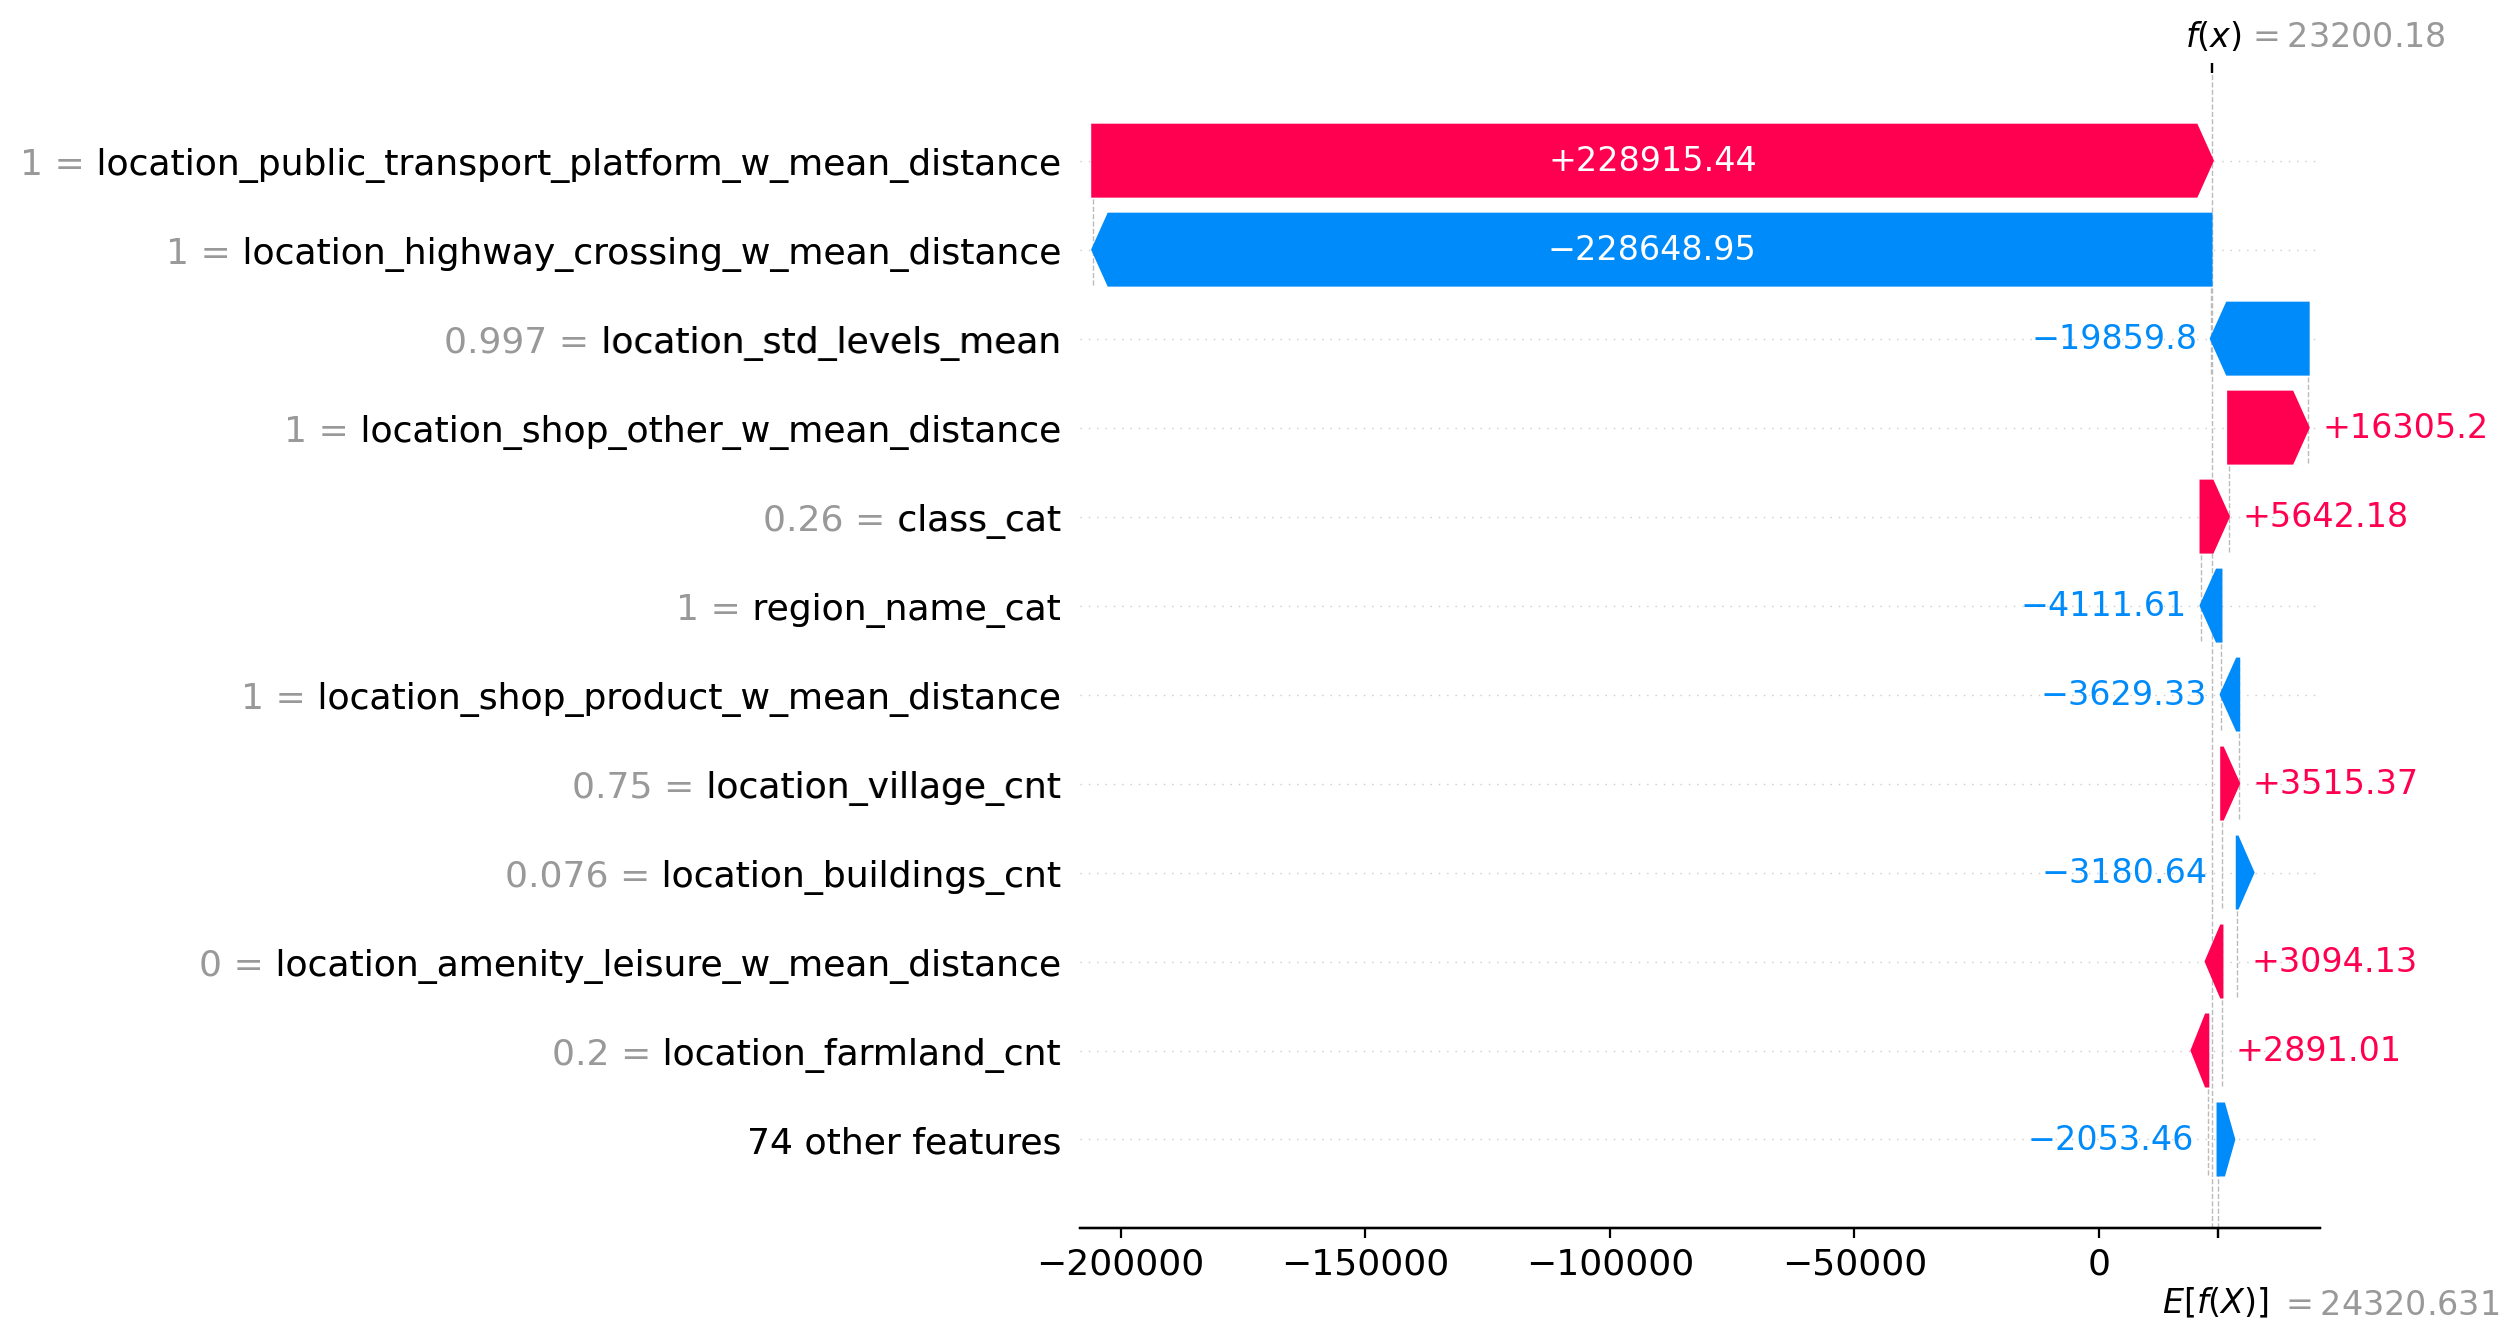

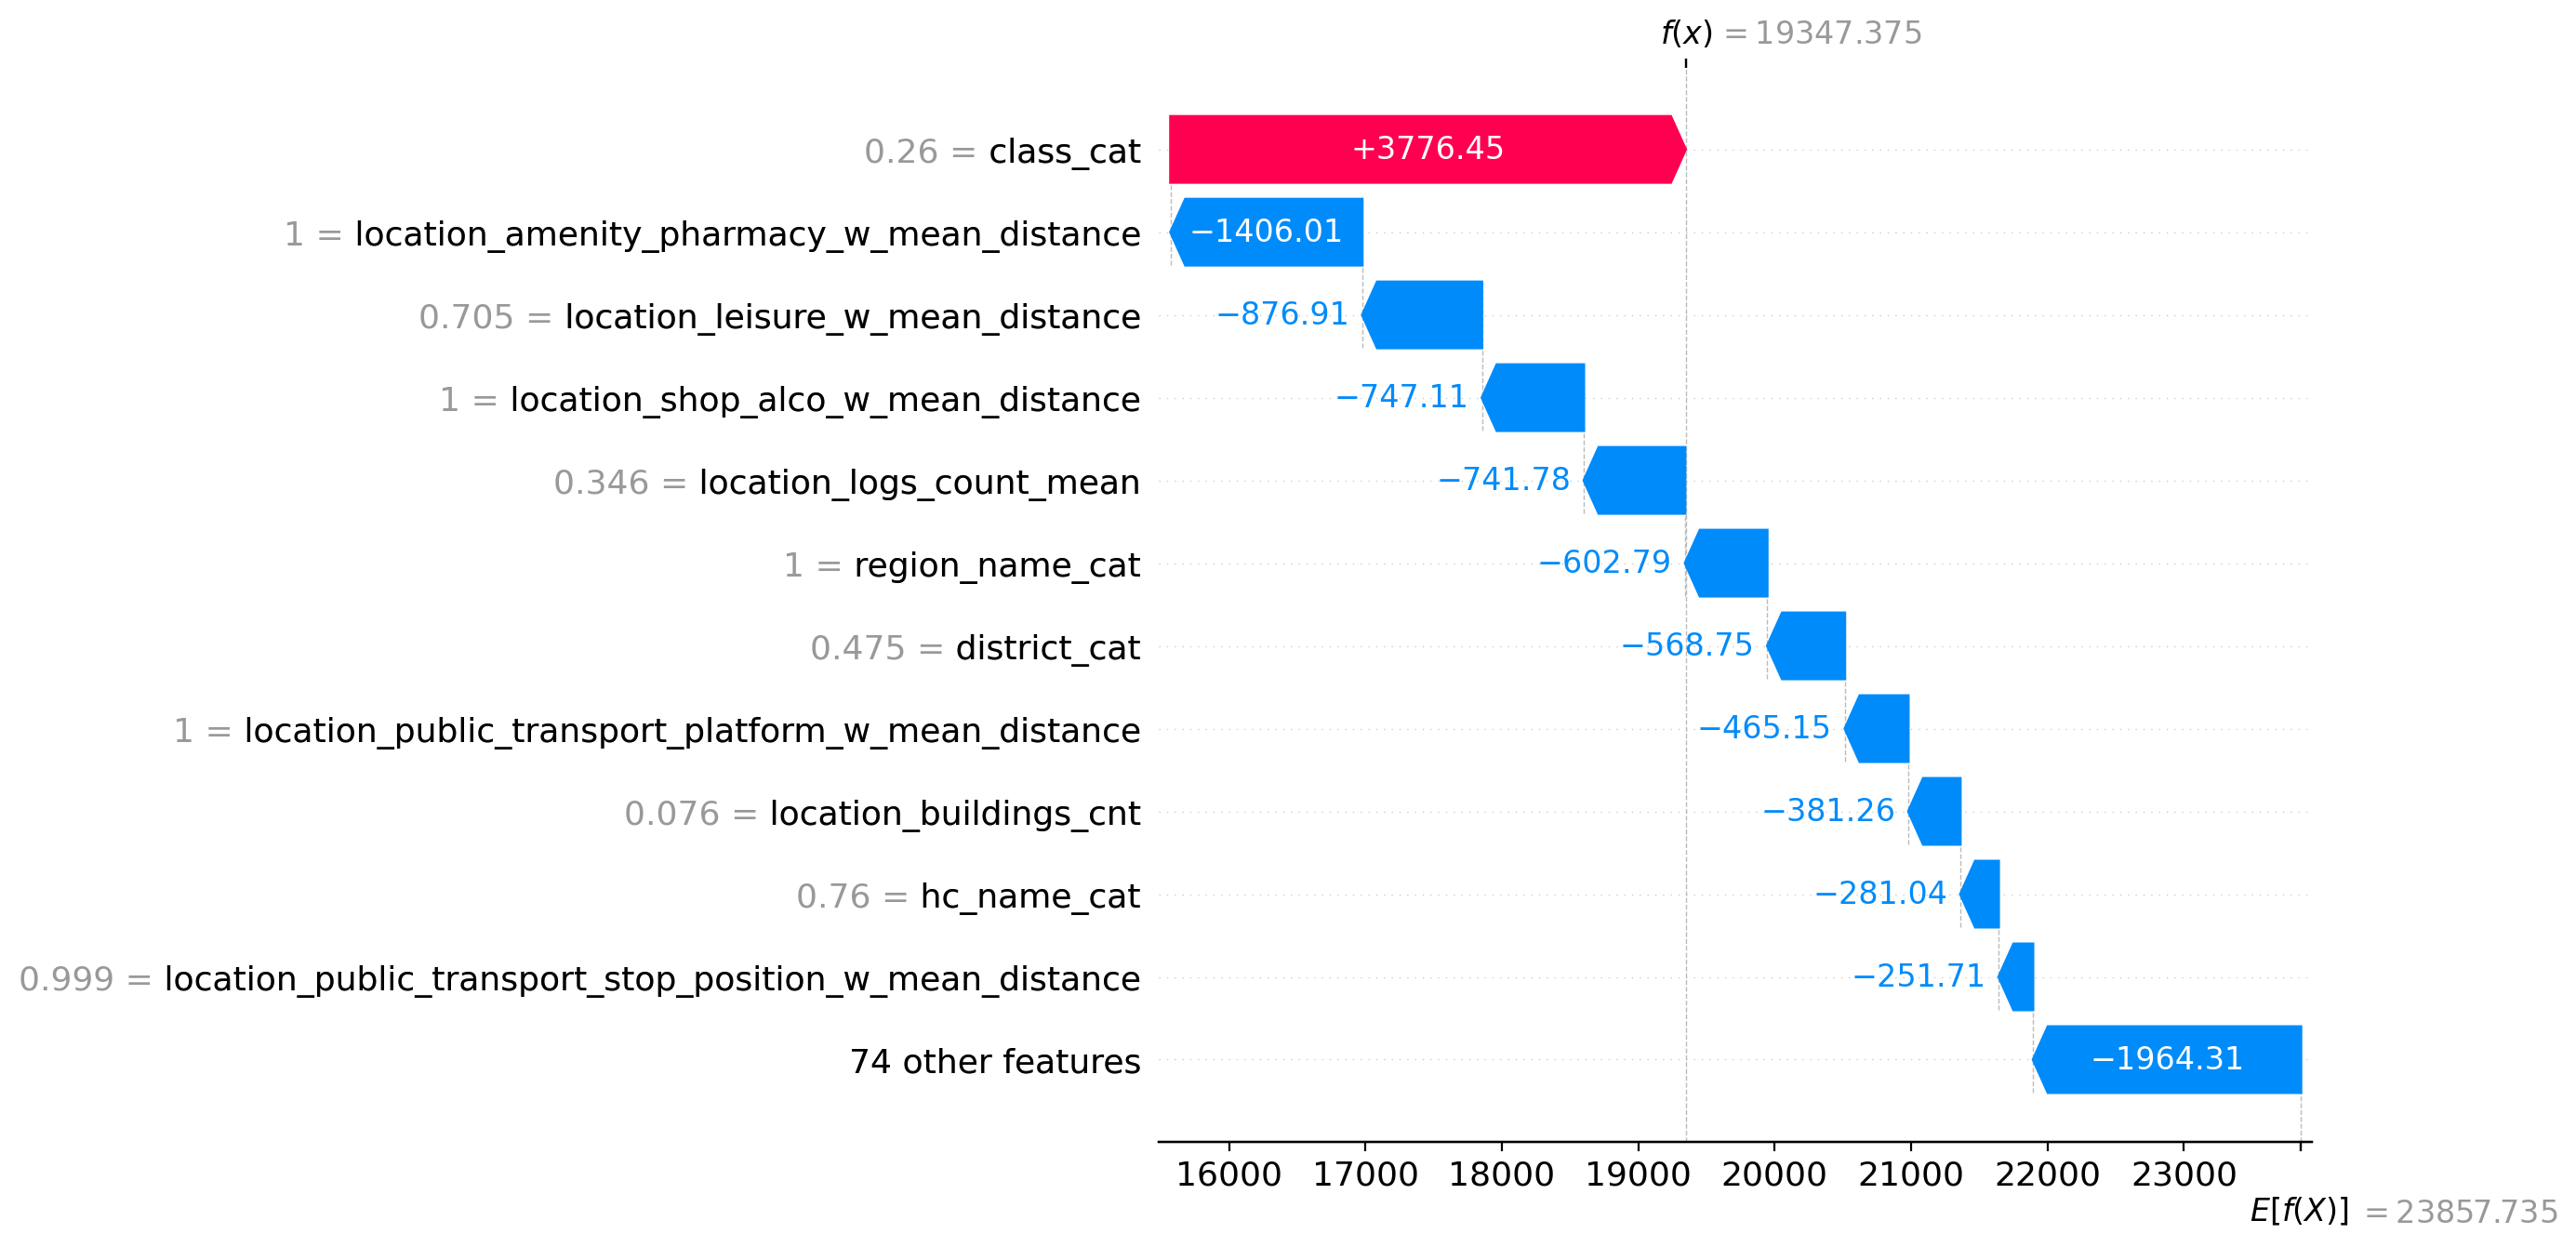

In [36]:
import shap

course_table_index = 17 
explain_position = min(course_table_index, len(X_test_minmax) - 1)
x_explain = X_test_minmax.iloc[[explain_position]]
linear_shap_explainer = shap.Explainer(lin_minmax, X_train_minmax)
linear_shap_values = linear_shap_explainer(x_explain)
gbr_shap_explainer = shap.Explainer(gbr_minmax.predict, X_train_minmax.sample(300, random_state=RANDOM_STATE))
gbr_shap_values = gbr_shap_explainer(x_explain, max_evals=2 * X_train_minmax.shape[1] + 1)
shap.plots.waterfall(linear_shap_values[0], max_display=12)
plt.show()
shap.plots.waterfall(gbr_shap_values[0], max_display=12)
plt.show()


In [37]:
display(pd.Series(np.abs(linear_shap_values.values[0]), index=feature_names).sort_values(ascending=False).head(5).to_frame('abs_shap'))
display(pd.Series(np.abs(gbr_shap_values.values[0]), index=feature_names).sort_values(ascending=False).head(5).to_frame('abs_shap'))
categorical_feature = 'region_name_cat'
X_onehot = data.drop(columns=['price_target']).copy()
X_onehot['agreement_date'] = pd.to_datetime(X_onehot['agreement_date'])
X_onehot['agreement_year'] = X_onehot['agreement_date'].dt.year
X_onehot['agreement_month'] = X_onehot['agreement_date'].dt.month
X_onehot['agreement_day'] = X_onehot['agreement_date'].dt.day
X_onehot['agreement_dayofweek'] = X_onehot['agreement_date'].dt.dayofweek
X_onehot = X_onehot.drop(columns=['agreement_date'])
X_onehot['rooms_4'] = X_onehot['rooms_4'].map(rooms_map)
X_onehot = pd.get_dummies(X_onehot, columns=[categorical_feature], dtype=float)
X_onehot_train = X_onehot.loc[X_train.index].fillna(X_onehot.loc[X_train.index].median(numeric_only=True))
X_onehot_test = X_onehot.loc[X_test.index].fillna(X_onehot.loc[X_train.index].median(numeric_only=True))
onehot_scaler = MinMaxScaler()
X_onehot_train_scaled = pd.DataFrame(onehot_scaler.fit_transform(X_onehot_train), columns=X_onehot_train.columns, index=X_onehot_train.index)
X_onehot_test_scaled = pd.DataFrame(onehot_scaler.transform(X_onehot_test), columns=X_onehot_test.columns, index=X_onehot_test.index)
onehot_model = LinearRegression().fit(X_onehot_train_scaled, y_train)
onehot_values = shap.Explainer(onehot_model, X_onehot_train_scaled)(X_onehot_test_scaled.iloc[[explain_position]])
dummy_cols = [c for c in X_onehot_train_scaled.columns if c.startswith(f'{categorical_feature}_')]
dummy_sum = float(pd.Series(onehot_values.values[0], index=X_onehot_train_scaled.columns)[dummy_cols].sum())
ordinal_value = float(pd.Series(linear_shap_values.values[0], index=feature_names)[categorical_feature])
print('Вклад в ordinal-кодировке:', round(ordinal_value, 4))
print('Сумма вкладов dummy-столбцов:', round(dummy_sum, 4))


,abs_shap
location_public_transport_platform_w_mean_distance,228915.438833
location_highway_crossing_w_mean_distance,228648.945756
location_std_levels_mean,19859.797709
location_shop_other_w_mean_distance,16305.201244
class_cat,5642.175421


,abs_shap
class_cat,3776.452530
location_amenity_pharmacy_w_mean_distance,1406.007501
location_leisure_w_mean_distance,876.905863
location_shop_alco_w_mean_distance,747.111162
location_logs_count_mean,741.776011


Вклад в ordinal-кодировке: -4111.6111
Сумма вкладов dummy-столбцов: -4111.6111
